# Swin Tiny MultiSeed (ResNet50) - ACL Classifier

**Multi-seed training with 10 different random seeds to study model robustness**

Pipeline para entrenar modelos Swin Transformer Tiny con múltiples seeds para evaluar la robustez del modelo.

**Objetivos:**
- Entrenar cada plano anatómico 10 veces con diferentes seeds (42-51)
- Analizar la variabilidad de las métricas entre seeds
- Identificar el mejor modelo para cada plano
- Proporcionar estimaciones de robustez (media ± desviación estándar)

## 1⃣ Imports y Configuración

In [1]:
# Imports estándar
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')
import gc

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas y evaluación
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Módulos locales
import sys
sys.path.insert(0, '../../src')

from gpu_config import device, VIT_GPU_IDS, CNN_GPU_ID
from models import SwinMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_train_transform, get_val_test_transform
from training_utils import train_model

print(" Todos los módulos importados exitosamente")

GPU CONFIGURATION
Device: cuda
GPUs disponibles: 4
  GPU 0: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 1: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 2: NVIDIA H100 PCIe
    Memoria: 85.02 GB
  GPU 3: NVIDIA H100 PCIe
    Memoria: 85.02 GB

 Asignación de GPUs:
  ViT Training: GPUs [0, 1, 2, 3]
  CNN Pre-processing: GPU 0

 Todos los módulos importados exitosamente


## 2⃣ Configuración Global para Multi-Seed

In [3]:
# ==========================================
# RUTAS Y DIRECTORIOS
# ==========================================
DATA_PATH = Path('../../data')
CHECKPOINT_DIR = Path('../../checkpoints/swin_tiny_multiseed_legacy')
SLICE_INDICES_DIR = DATA_PATH / 'slice_indices_final'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# CONFIGURACION MULTI-SEED
# ==========================================
NUM_SEEDS = 10
SEEDS = list(range(42, 42 + NUM_SEEDS))  # Seeds 42-51

# ==========================================
# SLICE SELECTION STRATEGY
# ==========================================
PLANE_CONFIG = {
    'sagittal': {'num_slices': 5, 'pooling_mode': 'attention'},
    'coronal': {'num_slices': 10, 'pooling_mode': 'attention'},
    'axial': {'num_slices': 10, 'pooling_mode': 'attention'}
}

PLANES = ['sagittal', 'coronal', 'axial']

IMAGE_SIZE = 256
NUM_CLASSES = 1
BATCH_SIZE = 32
NUM_WORKERS = 8
SEED = 42
NUM_EPOCHS = 100

# ==========================================
# AUGMENTATION CONFIGURATION
# ==========================================
AUGMENTATION_MODE_PER_PLANE = {
    'sagittal': 'aggressive',
    'coronal': 'aggressive',
    'axial': 'aggressive'
}

# ==========================================
# CONFIGURACION ESPECIFICA POR PLANO (Swin Tiny)
# ==========================================
PLANE_SPECIFIC_CONFIG = {
    'sagittal': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.5e-3,
        'dropout_input': 0.42,
        'dropout_dense': 0.32,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 12,
        'label_smoothing': 0.17,
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 5,
        'status': 'Swin Tiny - baseline estable'
    },
    'coronal': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.5e-3,
        'dropout_input': 0.42,
        'dropout_dense': 0.32,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 40,
        'label_smoothing': 0.17,
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': True,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 15,
        'pos_weight_factor': 1.0,
        'status': 'ATTENTION pooling + paciencia larga para seeds lentas'
    },
    'axial': {
        'learning_rate': 1.3e-4,
        'weight_decay': 1.0e-3,
        'dropout_input': 0.0,
        'dropout_dense': 0.2,
        'use_scheduler': False,
        'use_grad_clip': True,
        'grad_clip_norm': 1.0,
        'early_stopping_patience': 30,
        'label_smoothing': 0.05,
        'warmup_epochs': 0,
        'use_lr_plateau_scheduler': False,
        'lr_reduction_factor': 0.5,
        'lr_plateau_patience': 8,
        'status': 'Swin Tiny - config optimizada'
    }
}

print(f"\n{'='*100}")
print(f"Swin Tiny MULTISEED - CONFIGURACION")
print(f"{'='*100}")
print(f"Seeds: {SEEDS}")
print(f"Num seeds: {NUM_SEEDS}")
print(f"Data path: {DATA_PATH}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Planes: {PLANES}")
print(f"{'='*100}\n")


Swin Tiny MULTISEED - CONFIGURACION
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Num seeds: 10
Data path: ../../data
Checkpoint dir: ../../checkpoints/swin_tiny_multiseed_legacy
Num epochs: 100
Batch size: 32
Image size: 256
Planes: ['sagittal', 'coronal', 'axial']



## 3⃣ Función de Entrenamiento Multi-Seed

In [4]:
def set_seed(seed):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def init_attention_weights(model, seed):
    """
    Initialize attention pooling weights with seed-aware strategy.

    This ensures better convergence across all seeds by using:
    1. Xavier uniform initialization (more stable than default Kaiming)
    2. Small bias initialization (helps with softmax stability)
    """
    model_to_init = model.module if isinstance(model, nn.DataParallel) else model

    if hasattr(model_to_init, 'pooling') and hasattr(model_to_init.pooling, 'attention'):
 # Access the attention layers inside the pooling module
        attention_net = model_to_init.pooling.attention

 # Find all Linear layers
        for layer in attention_net:
            if isinstance(layer, nn.Linear):
 # Xavier uniform - more stable than Kaiming
                nn.init.xavier_uniform_(layer.weight)

 # Small bias - helps with softmax normalization
                if layer.bias is not None:
                    nn.init.normal_(layer.bias, mean=0.0, std=0.01)

def train_plane_multiseed(plane, num_seeds=10):
    """Train a plane with multiple seeds"""
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', 'attention')

    histories_all_seeds = {}
    best_auc_per_seed = []
    best_f1_per_seed = []
    seed_dirs = []

 # Create dataset once (same for all seeds)
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    for seed_idx, seed in enumerate(SEEDS, 1):
        print(f"\n{'='*80}")
        print(f" Seed {seed_idx}/{num_seeds}: SEED={seed}")
        print(f"{'='*80}\n")

 # Set random seed
        set_seed(seed)

 # Create fresh dataloaders with seed
        train_loader = DataLoader(
            train_dataset, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=True, generator=torch.Generator().manual_seed(seed)
        )
        val_loader = DataLoader(
            val_dataset, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=True
        )

 # Create fresh model
        model = SwinMultiSliceClassifier(
            num_classes=NUM_CLASSES,
            pretrained=True,
            pooling_mode=plane_pooling_mode,
            dropout_input=cfg['dropout_input'],
            dropout_dense=cfg['dropout_dense']
        )

        model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
        model = model.to(device)

 # NEW: Initialize attention weights with robust strategy
        if plane_pooling_mode == 'attention':
            init_attention_weights(model, seed)
            print(f" Attention weights initialized (Xavier uniform + seed-aware bias)\n")

 # Create seed-specific checkpoint dir
        seed_checkpoint_dir = CHECKPOINT_DIR / f"seed_{seed}"

 # Train
        history, best_auc, best_f1 = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            device=device,
            save_dir=seed_checkpoint_dir,
            plane_name=f"{plane}_seed{seed}",
            learning_rate=cfg['learning_rate'],
            weight_decay=cfg['weight_decay'],
            label_smoothing=cfg.get('label_smoothing', 0.05),
            use_scheduler=cfg.get('use_scheduler', False),
            use_grad_clip=cfg.get('use_grad_clip', False),
            grad_clip_norm=cfg.get('grad_clip_norm', 1.0),
            early_stopping_patience=cfg.get('early_stopping_patience', 15),
            dropout_input=cfg['dropout_input'],
            dropout_dense=cfg['dropout_dense'],
            augmentation_mode=aug_mode,
            use_wandb=False,
            warmup_epochs=cfg.get('warmup_epochs', 3),
            use_lr_plateau_scheduler=cfg.get('use_lr_plateau_scheduler', False),
            lr_reduction_factor=cfg.get('lr_reduction_factor', 0.5),
            lr_plateau_patience=cfg.get('lr_plateau_patience', 5),
            pos_weight_factor=cfg.get('pos_weight_factor', 1.0)
        )

        histories_all_seeds[seed] = history
        best_auc_per_seed.append(best_auc)
        best_f1_per_seed.append(best_f1)
        seed_dirs.append(seed_checkpoint_dir)

        print(f"  Seed {seed}: Best AUC = {best_auc:.4f}, Best F1 = {best_f1:.4f}")

 # Clear GPU memory
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return {
        'histories': histories_all_seeds,
        'best_auc_per_seed': best_auc_per_seed,
        'best_f1_per_seed': best_f1_per_seed,
        'seed_dirs': seed_dirs,
        'seeds': SEEDS
    }

print(" Función train_plane_multiseed definida con robust attention initialization")

 Función train_plane_multiseed definida con robust attention initialization


## 4⃣ Entrenar Todos los Planos (Multi-Seed)

In [5]:
train_sagittal = False
train_coronal = True
train_axial = False

results_all_seeds = {}

if train_sagittal:
    print(f"\n{'='*100}\n ENTRENANDO SAGITTAL CON {NUM_SEEDS} SEEDS\n{'='*100}\n")
    results_all_seeds['sagittal'] = train_plane_multiseed('sagittal', NUM_SEEDS)

if train_coronal:
    print(f"\n{'='*100}\n ENTRENANDO CORONAL CON {NUM_SEEDS} SEEDS\n{'='*100}\n")
    results_all_seeds['coronal'] = train_plane_multiseed('coronal', NUM_SEEDS)

if train_axial:
    print(f"\n{'='*100}\n ENTRENANDO AXIAL CON {NUM_SEEDS} SEEDS\n{'='*100}\n")
    results_all_seeds['axial'] = train_plane_multiseed('axial', NUM_SEEDS)

print("\n ENTRENAMIENTO MULTI-SEED COMPLETADO")


 ENTRENANDO CORONAL CON 10 SEEDS

 Dataset cargado: 875 casos
  Plane: coronal
  Augmentation: aggressive
  Índices cacheados: ../../data/slice_indices_final/train_coronal_indices.json
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_coronal_indices.json

 Seed 1/10: SEED=42

 Attention weights initialized (Xavier uniform + seed-aware bias)


ENTRENANDO MODELO: CORONAL_SEED42
LR=0.00013, WD=0.0015, Scheduler=False, GradClip=True
Dropout: Input=0.42, Dense=0.32
Augmentation: aggressive

 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives × 1.0)

Epoch 1/100 (LR=1.30e-04): Train: Loss=1.1813, AUC=0.4826 | Val: Loss=1.1573, AUC=0.5857, F1=0.3214  Best AUC!
Epoch 2/100 (LR=1.30e-04): Train: Loss=1.1844, AUC=0.4851 | Val: Loss=1.1573, AUC=0.5380, F1=0.3214
Epoch 3/100 (LR=1.30e-04): Train: Loss=1.1781, AUC=0.5097 | Val: Loss=1.1599, AUC=0.4722, F1=0.3214
Epoch 4/100 (LR=1.30e

## 5⃣ Visualizar Todas las Semillas (Loss y AUC Combinados)

 Gráfico guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_curves_coronal.png


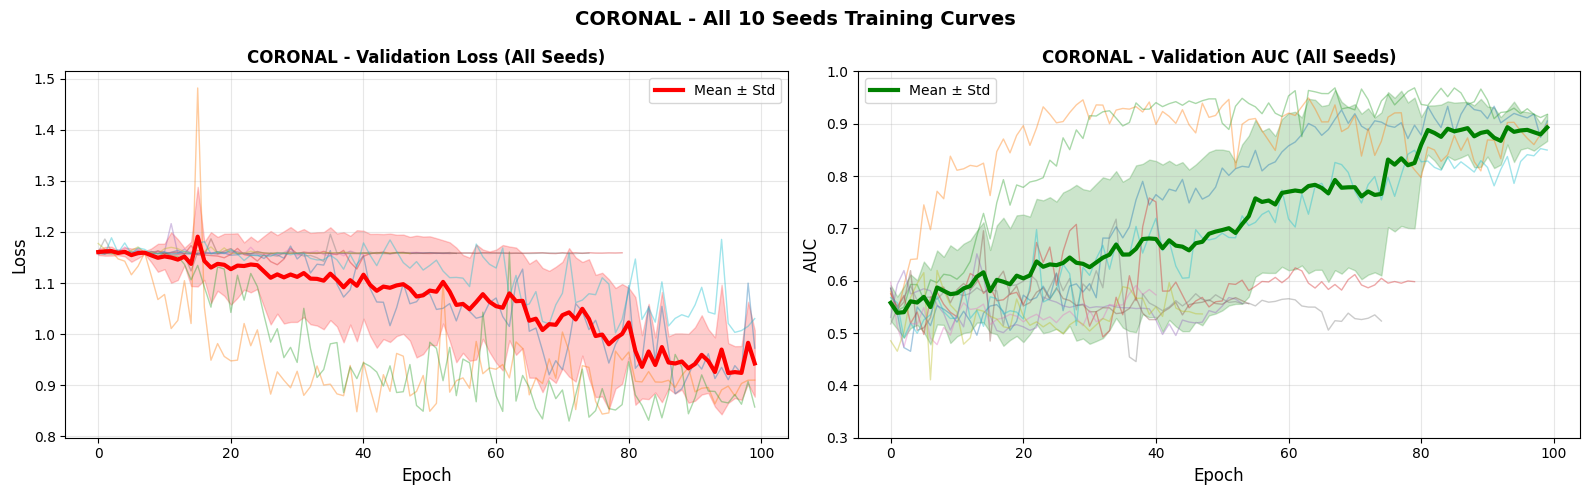

In [6]:
# For each plane, create figure with all 10 seeds
for plane in PLANES:
    if plane in results_all_seeds:
        results = results_all_seeds[plane]
        histories = results['histories']
        best_auc_per_seed = results['best_auc_per_seed']
        seeds = results['seeds']

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f'{plane.upper()} - All {NUM_SEEDS} Seeds Training Curves', fontsize=14, fontweight='bold')

 # Plot Loss
        all_losses = []
        max_len_loss = 0
        for seed, history in histories.items():
            loss = history['val_loss_objective']
            axes[0].plot(loss, alpha=0.4, linewidth=1)
            all_losses.append(loss)
            max_len_loss = max(max_len_loss, len(loss))

 # Pad arrays to same length with NaN
        all_losses_padded = []
        for loss in all_losses:
            padded = np.full(max_len_loss, np.nan)
            padded[:len(loss)] = loss
            all_losses_padded.append(padded)
        all_losses_padded = np.array(all_losses_padded)

 # Add mean ± std (ignoring NaN)
        mean_loss = np.nanmean(all_losses_padded, axis=0)
        std_loss = np.nanstd(all_losses_padded, axis=0)
        axes[0].plot(mean_loss, 'r-', linewidth=3, label='Mean ± Std')
        axes[0].fill_between(range(len(mean_loss)), mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, color='red')
        axes[0].set_xlabel('Epoch', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].set_title(f'{plane.upper()} - Validation Loss (All Seeds)', fontsize=12, fontweight='bold')
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)

 # Plot AUC
        all_aucs = []
        max_len_auc = 0
        for seed, history in histories.items():
            auc = history['val_auc']
            axes[1].plot(auc, alpha=0.4, linewidth=1)
            all_aucs.append(auc)
            max_len_auc = max(max_len_auc, len(auc))

 # Pad arrays to same length with NaN
        all_aucs_padded = []
        for auc in all_aucs:
            padded = np.full(max_len_auc, np.nan)
            padded[:len(auc)] = auc
            all_aucs_padded.append(padded)
        all_aucs_padded = np.array(all_aucs_padded)

 # Add mean ± std (ignoring NaN)
        mean_auc = np.nanmean(all_aucs_padded, axis=0)
        std_auc = np.nanstd(all_aucs_padded, axis=0)
        axes[1].plot(mean_auc, 'g-', linewidth=3, label='Mean ± Std')
        axes[1].fill_between(range(len(mean_auc)), mean_auc - std_auc, mean_auc + std_auc, alpha=0.2, color='green')
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('AUC', fontsize=12)
        axes[1].set_title(f'{plane.upper()} - Validation AUC (All Seeds)', fontsize=12, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0.3, 1.0])

        plt.tight_layout()
        plot_path = CHECKPOINT_DIR / f"multiseed_curves_{plane}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f" Gráfico guardado: {plot_path}")
        plt.show()  # Mostrar en notebook
        plt.close('all')  # Limpiar memoria

## 5⃣ Bis - Visualización Mejorada (Train + Val)

 Gráfico detallado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_detailed_sagittal.png


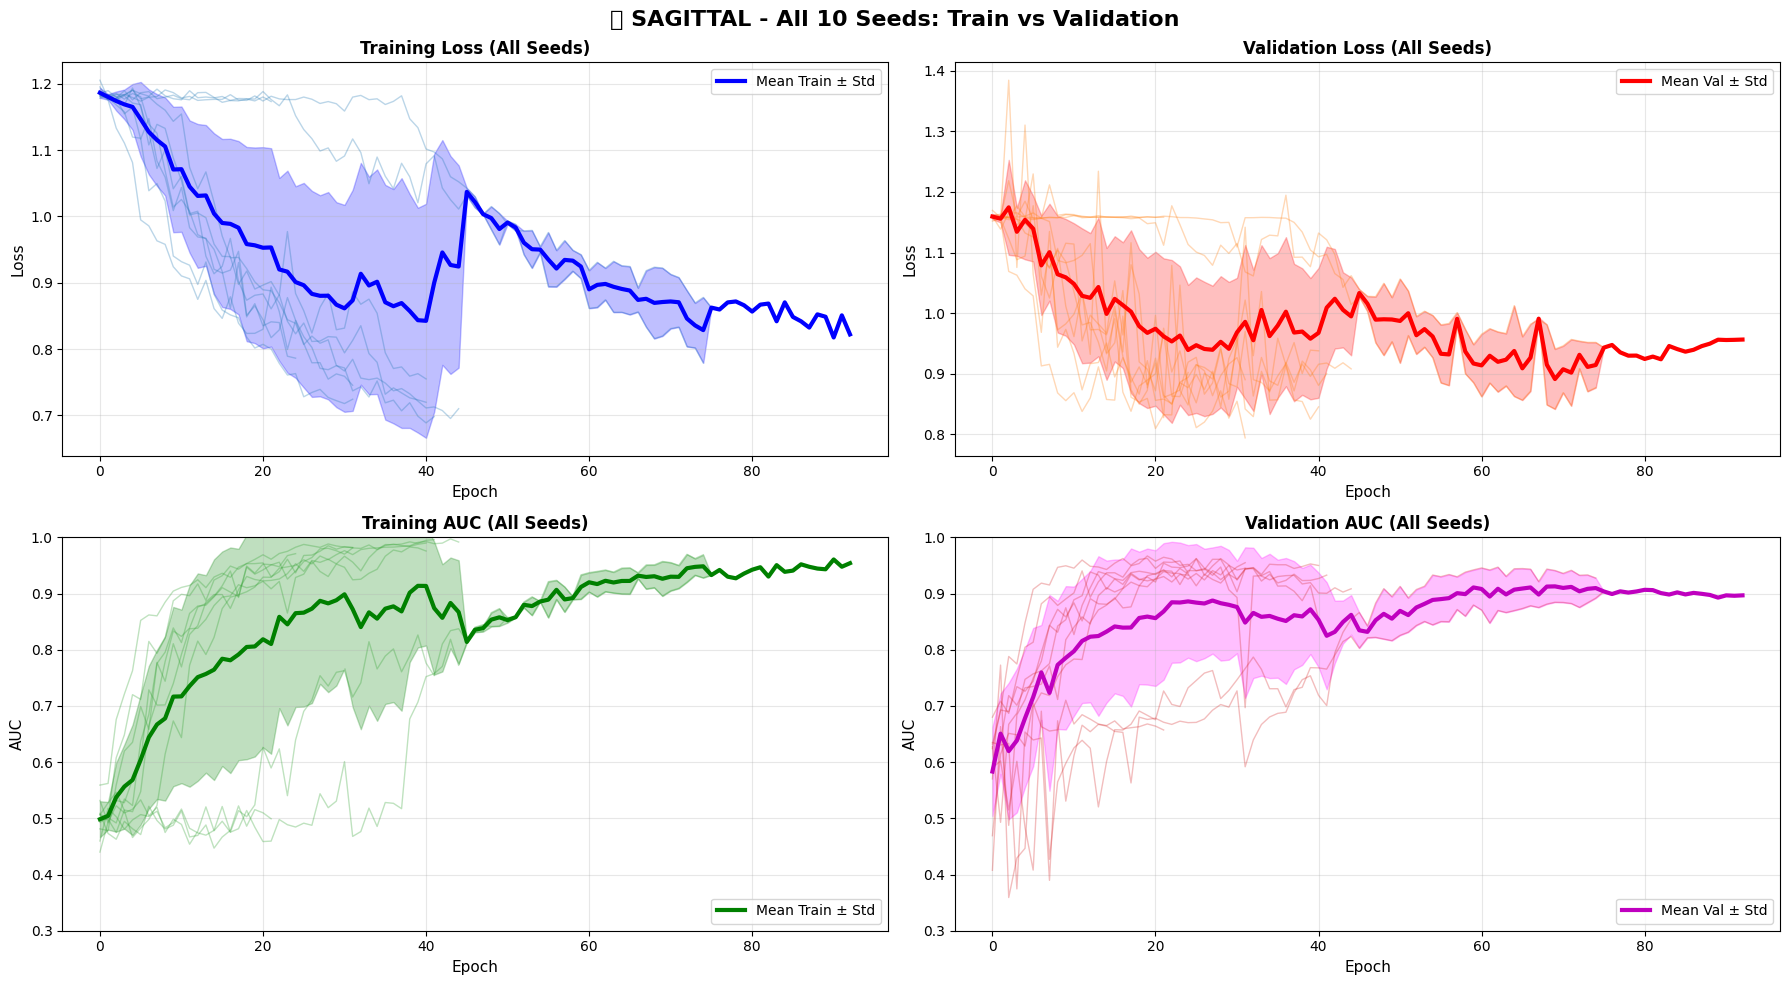

 Gráfico detallado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_detailed_coronal.png


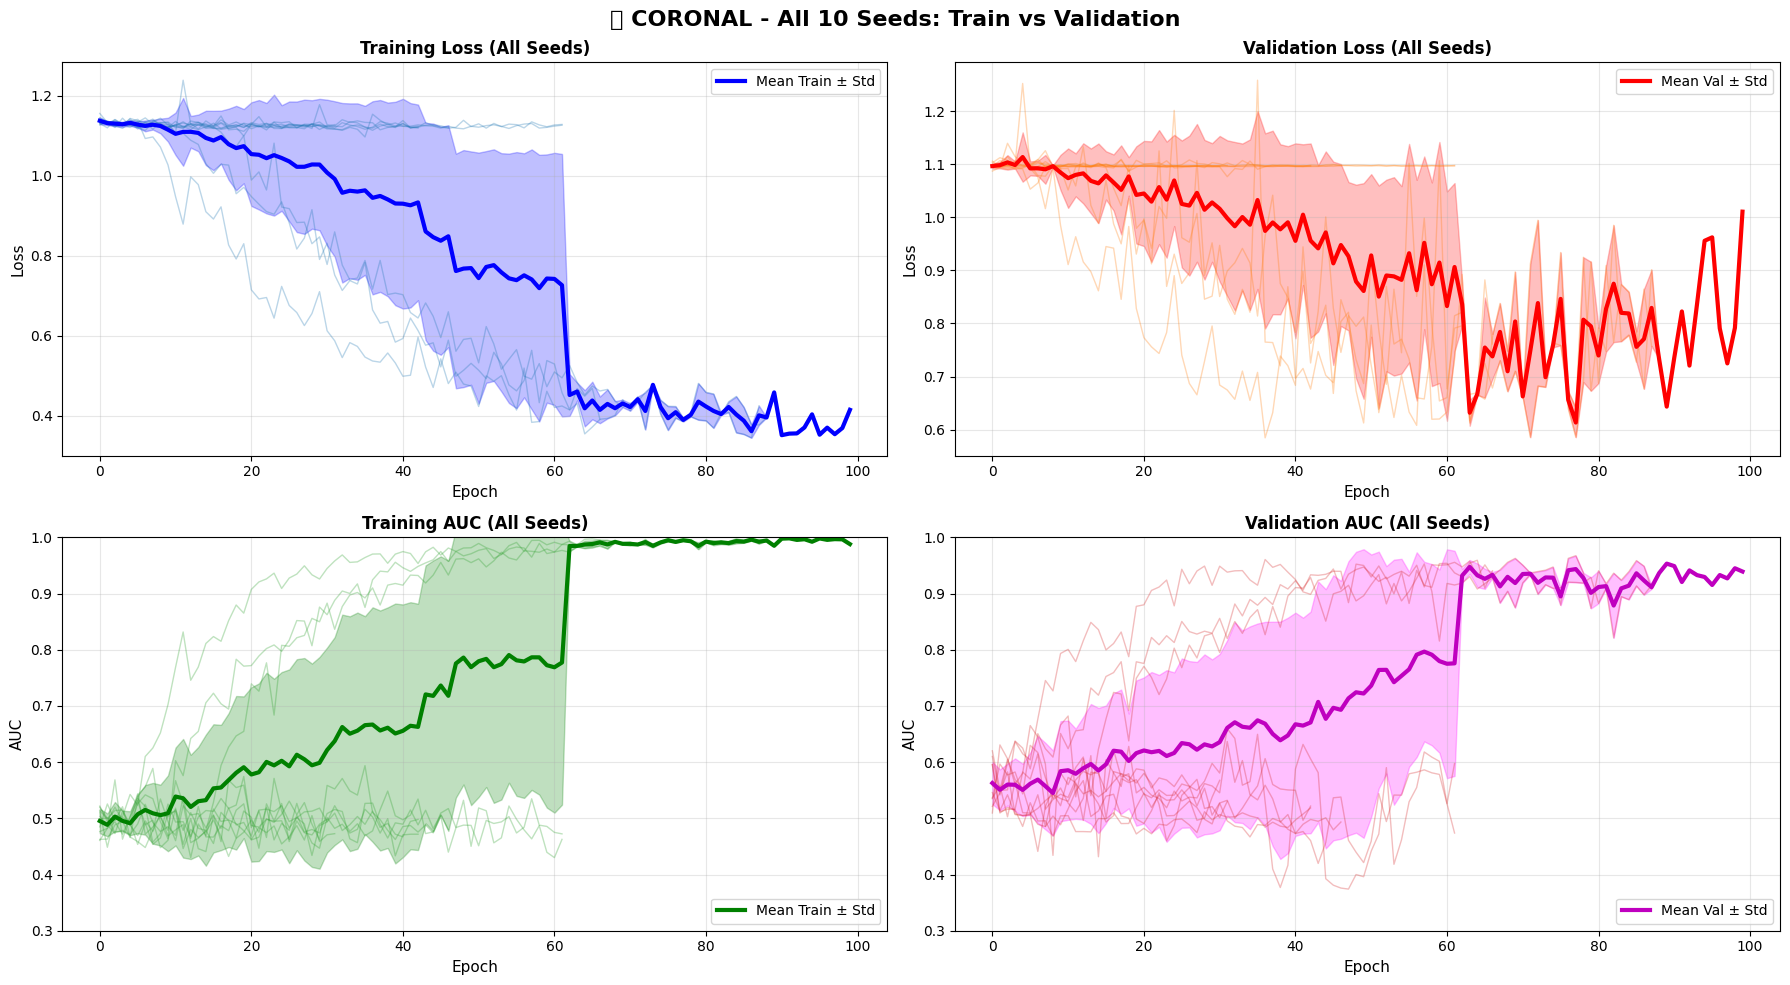

 Gráfico detallado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_detailed_axial.png


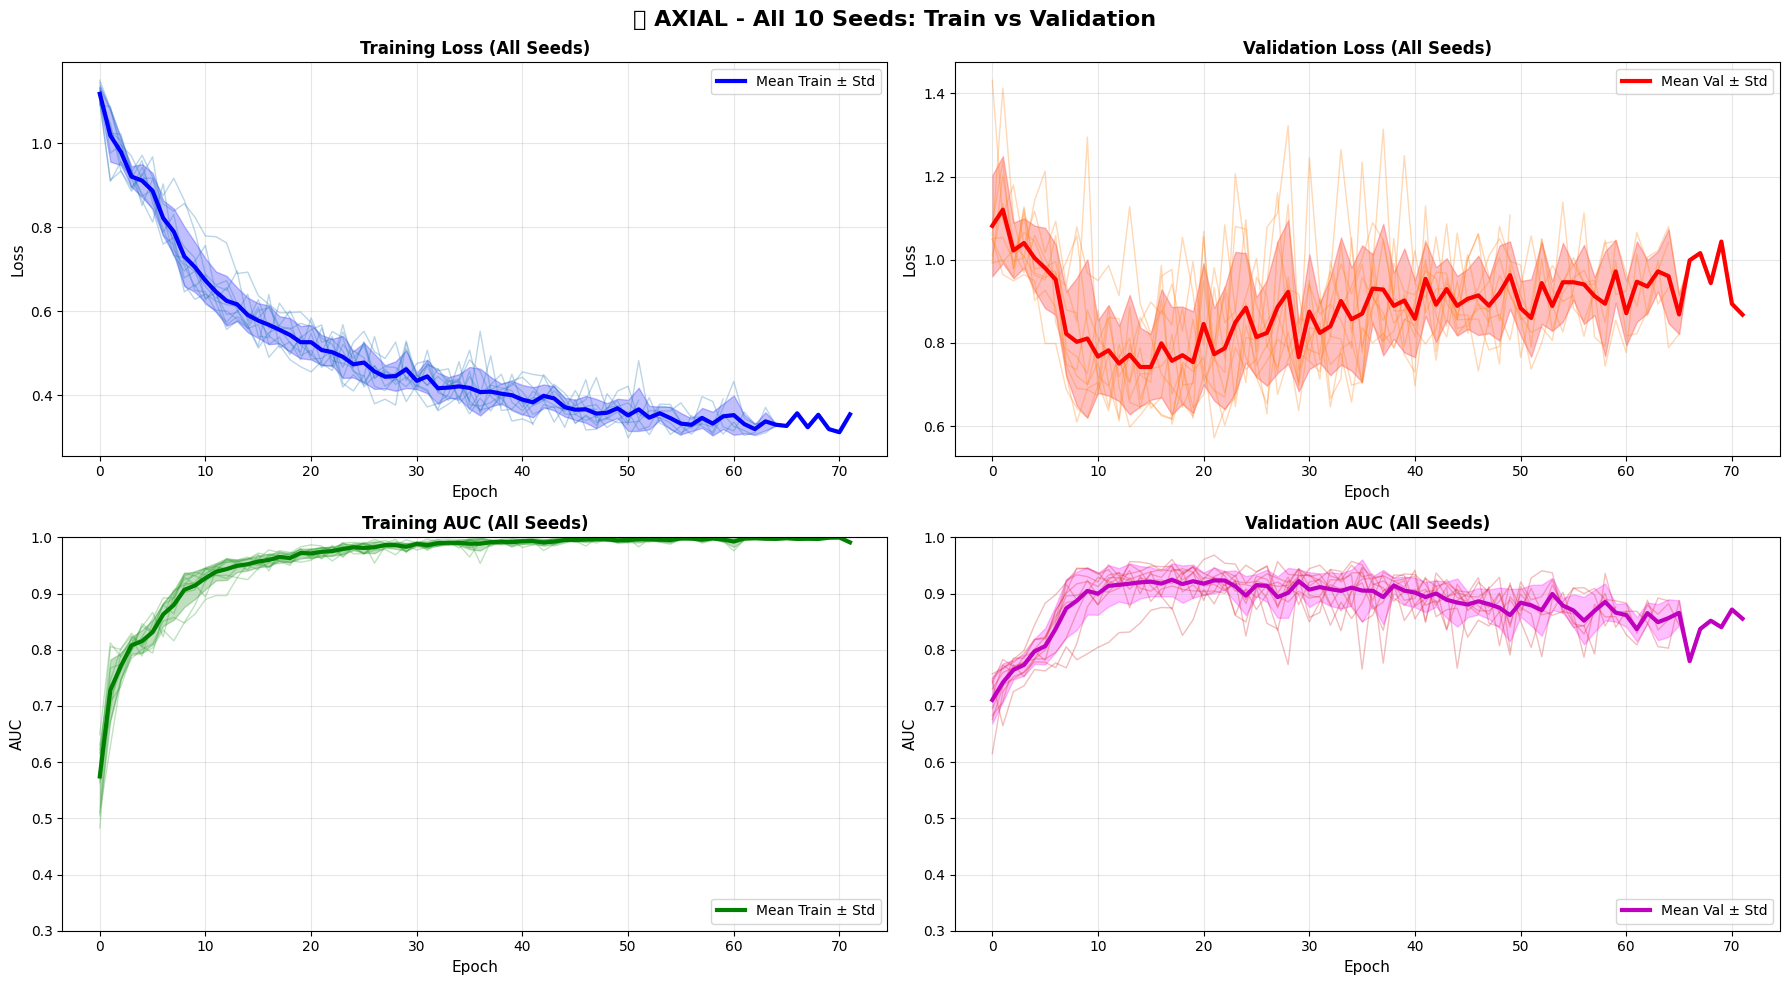

In [6]:
# Visualización mejorada: Train + Val para cada plano (4 subplots)
for plane in PLANES:
    if plane in results_all_seeds:
        results = results_all_seeds[plane]
        histories = results['histories']
        seeds = results['seeds']

        fig, axes = plt.subplots(2, 2, figsize=(18, 10))
        fig.suptitle(f' {plane.upper()} - All {NUM_SEEDS} Seeds: Train vs Validation', fontsize=16, fontweight='bold')

 # ============ LOSS TRAIN ============
        all_train_losses = []
        max_len_train_loss = 0
        for seed, history in histories.items():
            loss = history['train_loss']
            axes[0, 0].plot(loss, alpha=0.3, linewidth=1, color='#1f77b4')
            all_train_losses.append(loss)
            max_len_train_loss = max(max_len_train_loss, len(loss))

 # Pad and calculate mean ± std for train loss
        all_train_losses_padded = []
        for loss in all_train_losses:
            padded = np.full(max_len_train_loss, np.nan)
            padded[:len(loss)] = loss
            all_train_losses_padded.append(padded)
        all_train_losses_padded = np.array(all_train_losses_padded)
        mean_train_loss = np.nanmean(all_train_losses_padded, axis=0)
        std_train_loss = np.nanstd(all_train_losses_padded, axis=0)

        axes[0, 0].plot(mean_train_loss, 'b-', linewidth=3, label='Mean Train ± Std')
        axes[0, 0].fill_between(range(len(mean_train_loss)), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.25, color='blue')
        axes[0, 0].set_xlabel('Epoch', fontsize=11)
        axes[0, 0].set_ylabel('Loss', fontsize=11)
        axes[0, 0].set_title('Training Loss (All Seeds)', fontsize=12, fontweight='bold')
        axes[0, 0].legend(fontsize=10, loc='upper right')
        axes[0, 0].grid(True, alpha=0.3)

 # ============ LOSS VAL ============
        all_val_losses = []
        max_len_val_loss = 0
        for seed, history in histories.items():
            loss = history['val_loss_objective']
            axes[0, 1].plot(loss, alpha=0.3, linewidth=1, color='#ff7f0e')
            all_val_losses.append(loss)
            max_len_val_loss = max(max_len_val_loss, len(loss))

 # Pad and calculate mean ± std for val loss
        all_val_losses_padded = []
        for loss in all_val_losses:
            padded = np.full(max_len_val_loss, np.nan)
            padded[:len(loss)] = loss
            all_val_losses_padded.append(padded)
        all_val_losses_padded = np.array(all_val_losses_padded)
        mean_val_loss = np.nanmean(all_val_losses_padded, axis=0)
        std_val_loss = np.nanstd(all_val_losses_padded, axis=0)

        axes[0, 1].plot(mean_val_loss, 'r-', linewidth=3, label='Mean Val ± Std')
        axes[0, 1].fill_between(range(len(mean_val_loss)), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.25, color='red')
        axes[0, 1].set_xlabel('Epoch', fontsize=11)
        axes[0, 1].set_ylabel('Loss', fontsize=11)
        axes[0, 1].set_title('Validation Loss (All Seeds)', fontsize=12, fontweight='bold')
        axes[0, 1].legend(fontsize=10, loc='upper right')
        axes[0, 1].grid(True, alpha=0.3)

 # ============ AUC TRAIN ============
        all_train_aucs = []
        max_len_train_auc = 0
        for seed, history in histories.items():
            auc = history['train_auc']
            axes[1, 0].plot(auc, alpha=0.3, linewidth=1, color='#2ca02c')
            all_train_aucs.append(auc)
            max_len_train_auc = max(max_len_train_auc, len(auc))

 # Pad and calculate mean ± std for train AUC
        all_train_aucs_padded = []
        for auc in all_train_aucs:
            padded = np.full(max_len_train_auc, np.nan)
            padded[:len(auc)] = auc
            all_train_aucs_padded.append(padded)
        all_train_aucs_padded = np.array(all_train_aucs_padded)
        mean_train_auc = np.nanmean(all_train_aucs_padded, axis=0)
        std_train_auc = np.nanstd(all_train_aucs_padded, axis=0)

        axes[1, 0].plot(mean_train_auc, 'g-', linewidth=3, label='Mean Train ± Std')
        axes[1, 0].fill_between(range(len(mean_train_auc)), mean_train_auc - std_train_auc, mean_train_auc + std_train_auc, alpha=0.25, color='green')
        axes[1, 0].set_xlabel('Epoch', fontsize=11)
        axes[1, 0].set_ylabel('AUC', fontsize=11)
        axes[1, 0].set_title('Training AUC (All Seeds)', fontsize=12, fontweight='bold')
        axes[1, 0].legend(fontsize=10, loc='lower right')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim([0.3, 1.0])

 # ============ AUC VAL ============
        all_val_aucs = []
        max_len_val_auc = 0
        for seed, history in histories.items():
            auc = history['val_auc']
            axes[1, 1].plot(auc, alpha=0.3, linewidth=1, color='#d62728')
            all_val_aucs.append(auc)
            max_len_val_auc = max(max_len_val_auc, len(auc))

 # Pad and calculate mean ± std for val AUC
        all_val_aucs_padded = []
        for auc in all_val_aucs:
            padded = np.full(max_len_val_auc, np.nan)
            padded[:len(auc)] = auc
            all_val_aucs_padded.append(padded)
        all_val_aucs_padded = np.array(all_val_aucs_padded)
        mean_val_auc = np.nanmean(all_val_aucs_padded, axis=0)
        std_val_auc = np.nanstd(all_val_aucs_padded, axis=0)

        axes[1, 1].plot(mean_val_auc, 'm-', linewidth=3, label='Mean Val ± Std')
        axes[1, 1].fill_between(range(len(mean_val_auc)), mean_val_auc - std_val_auc, mean_val_auc + std_val_auc, alpha=0.25, color='magenta')
        axes[1, 1].set_xlabel('Epoch', fontsize=11)
        axes[1, 1].set_ylabel('AUC', fontsize=11)
        axes[1, 1].set_title('Validation AUC (All Seeds)', fontsize=12, fontweight='bold')
        axes[1, 1].legend(fontsize=10, loc='lower right')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_ylim([0.3, 1.0])

        plt.tight_layout()
        plot_path = CHECKPOINT_DIR / f"multiseed_detailed_{plane}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f" Gráfico detallado guardado: {plot_path}")
        plt.show()  # Mostrar en notebook
        plt.close('all')  # Limpiar memoria

## 5⃣ Ter - Visualización Combinada (Train vs Val en 3 paneles)

 Gráfico combinado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_combined_sagittal.png


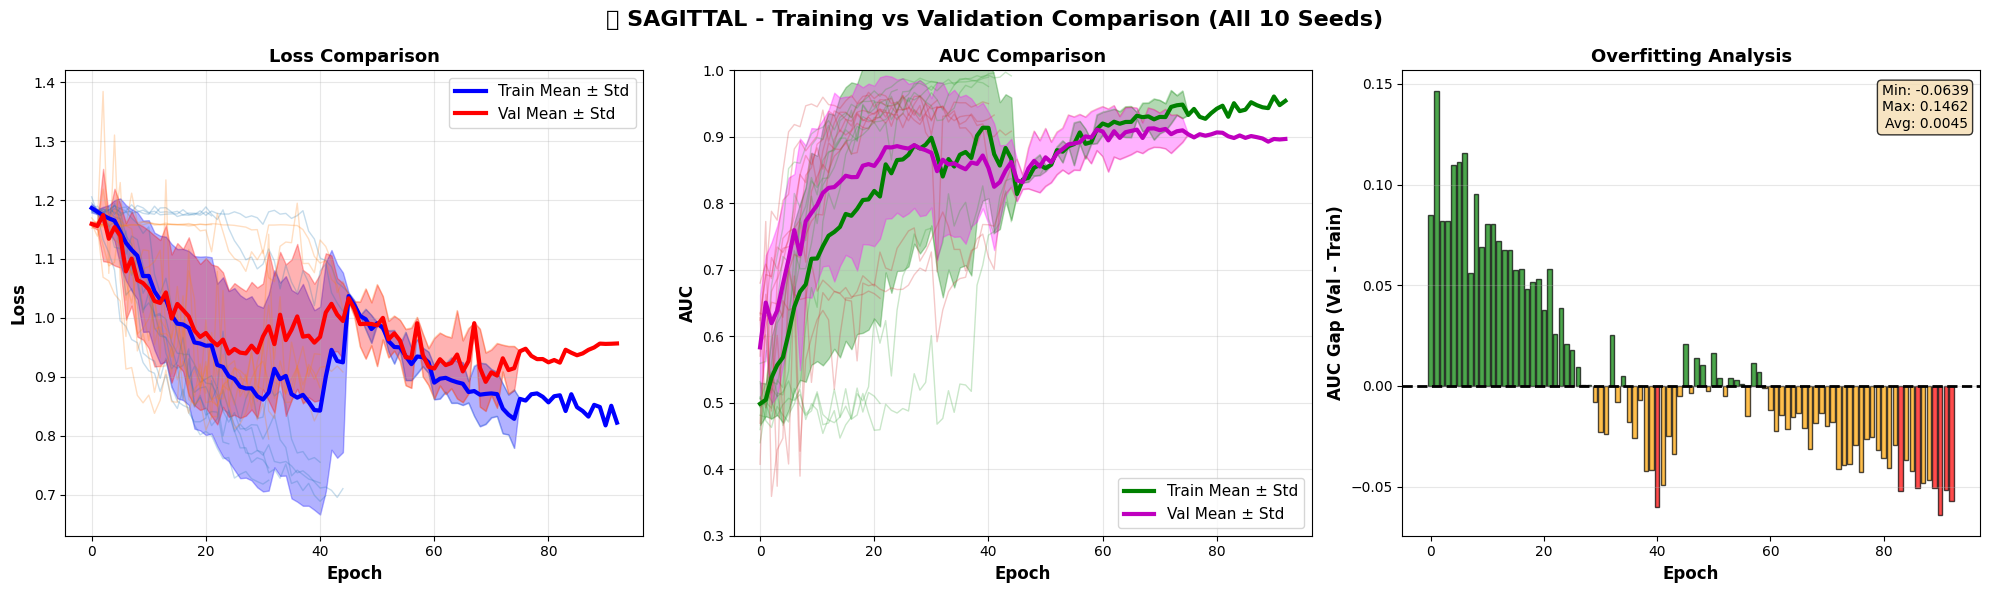

 Gráfico combinado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_combined_coronal.png


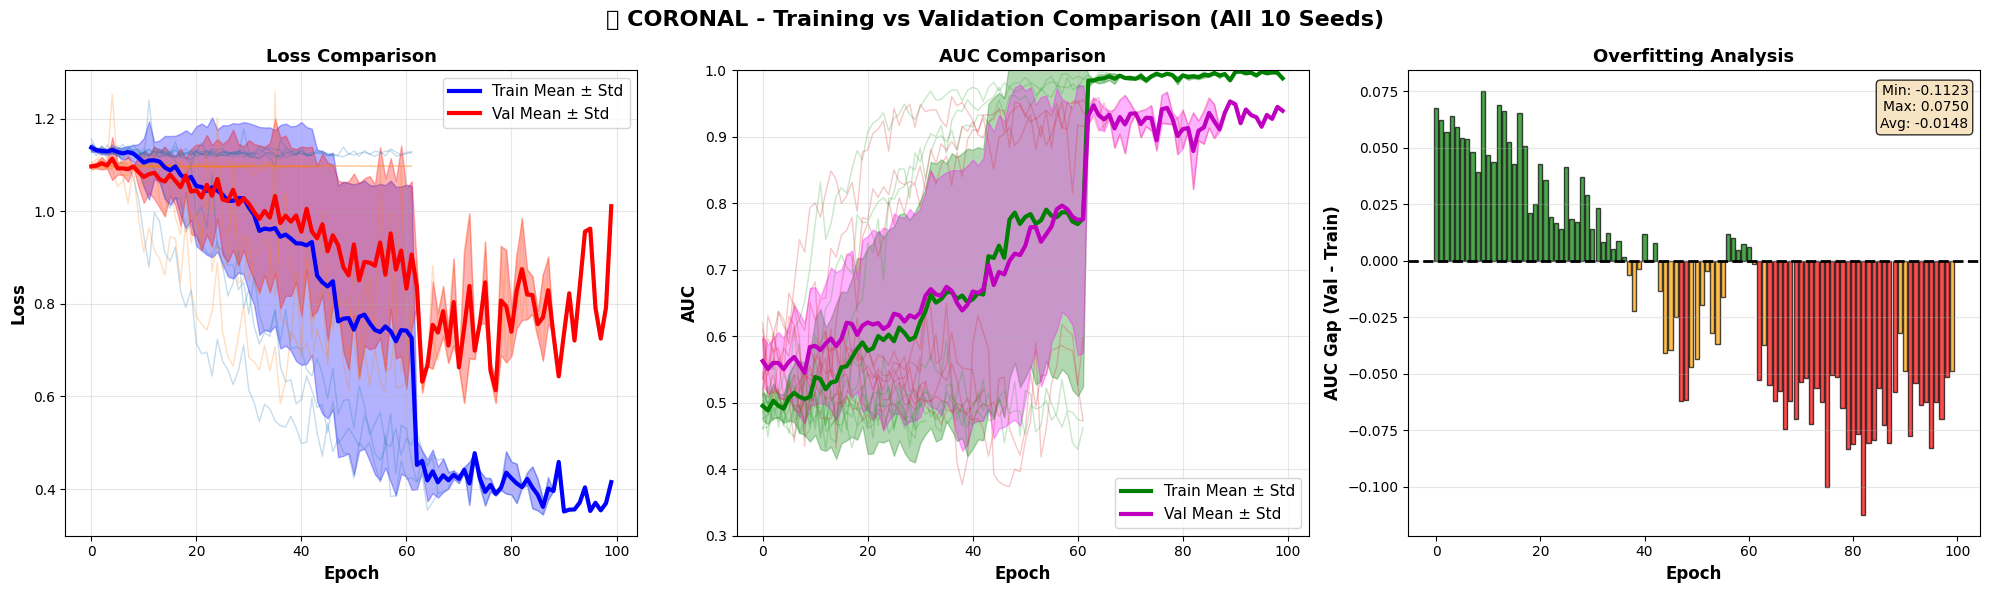

 Gráfico combinado guardado: ../../checkpoints/swin_tiny_multiseed_legacy/multiseed_combined_axial.png


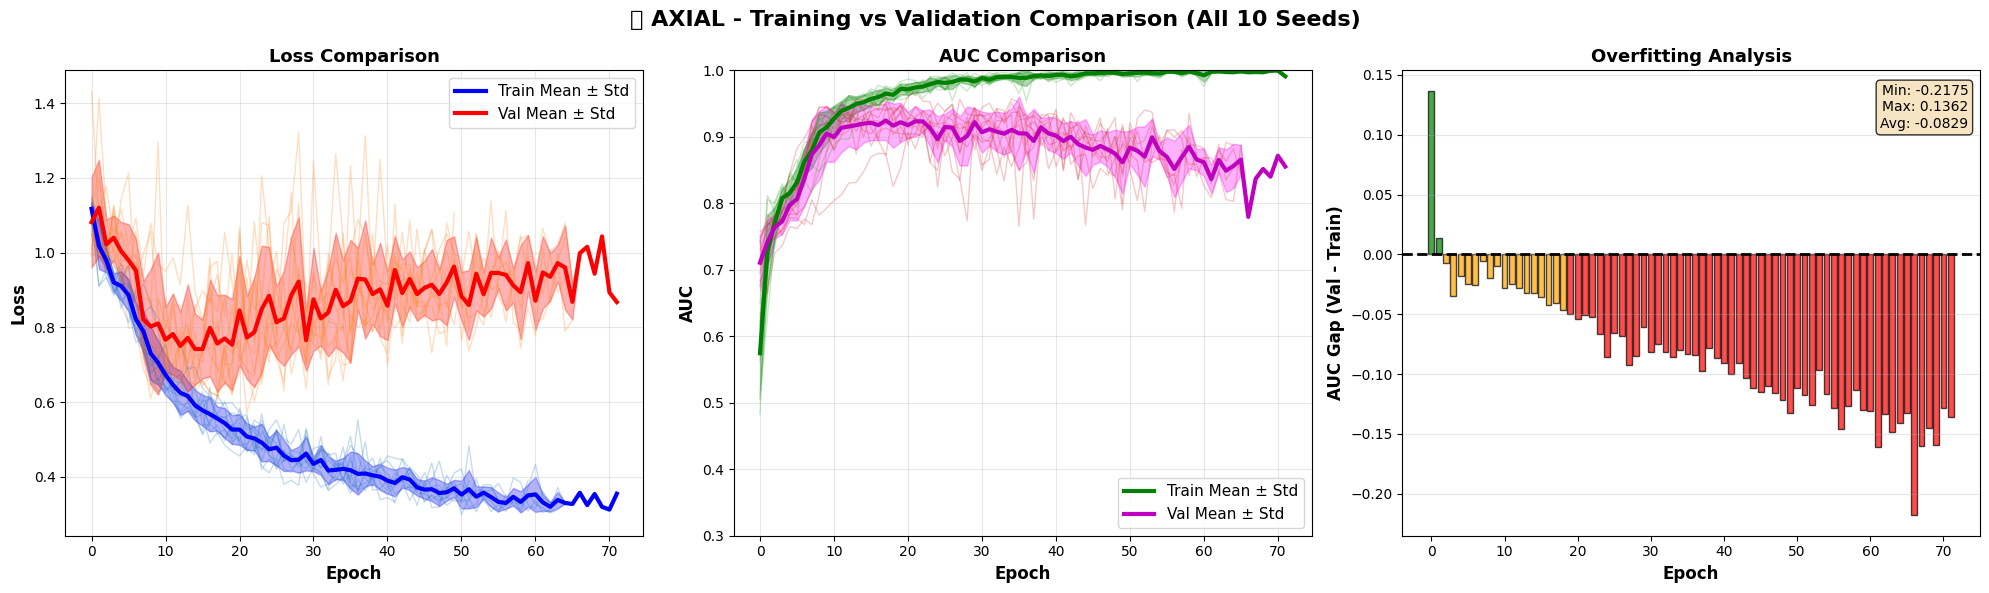

In [7]:
# Visualización combinada: Train vs Val en 3 paneles elegantes
for plane in PLANES:
    if plane in results_all_seeds:
        results = results_all_seeds[plane]
        histories = results['histories']
        seeds = results['seeds']

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f' {plane.upper()} - Training vs Validation Comparison (All {NUM_SEEDS} Seeds)', fontsize=16, fontweight='bold')

 # ============ LOSS PANEL ============
 # Train losses
        all_train_losses = []
        max_len_train_loss = 0
        for seed, history in histories.items():
            loss = history['train_loss']
            axes[0].plot(loss, alpha=0.25, linewidth=1, color='#1f77b4')
            all_train_losses.append(loss)
            max_len_train_loss = max(max_len_train_loss, len(loss))

        all_train_losses_padded = []
        for loss in all_train_losses:
            padded = np.full(max_len_train_loss, np.nan)
            padded[:len(loss)] = loss
            all_train_losses_padded.append(padded)
        all_train_losses_padded = np.array(all_train_losses_padded)
        mean_train_loss = np.nanmean(all_train_losses_padded, axis=0)
        std_train_loss = np.nanstd(all_train_losses_padded, axis=0)

 # Val losses
        all_val_losses = []
        max_len_val_loss = 0
        for seed, history in histories.items():
            loss = history['val_loss_objective']
            axes[0].plot(loss, alpha=0.25, linewidth=1, color='#ff7f0e')
            all_val_losses.append(loss)
            max_len_val_loss = max(max_len_val_loss, len(loss))

        all_val_losses_padded = []
        for loss in all_val_losses:
            padded = np.full(max_len_val_loss, np.nan)
            padded[:len(loss)] = loss
            all_val_losses_padded.append(padded)
        all_val_losses_padded = np.array(all_val_losses_padded)
        mean_val_loss = np.nanmean(all_val_losses_padded, axis=0)
        std_val_loss = np.nanstd(all_val_losses_padded, axis=0)

 # Plot means
        axes[0].plot(mean_train_loss, 'b-', linewidth=3, label='Train Mean ± Std')
        axes[0].fill_between(range(len(mean_train_loss)), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.3, color='blue')
        axes[0].plot(mean_val_loss, 'r-', linewidth=3, label='Val Mean ± Std')
        axes[0].fill_between(range(len(mean_val_loss)), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.3, color='red')
        axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
        axes[0].set_title('Loss Comparison', fontsize=13, fontweight='bold')
        axes[0].legend(fontsize=11, loc='upper right')
        axes[0].grid(True, alpha=0.3)

 # ============ AUC PANEL ============
 # Train AUCs
        all_train_aucs = []
        max_len_train_auc = 0
        for seed, history in histories.items():
            auc = history['train_auc']
            axes[1].plot(auc, alpha=0.25, linewidth=1, color='#2ca02c')
            all_train_aucs.append(auc)
            max_len_train_auc = max(max_len_train_auc, len(auc))

        all_train_aucs_padded = []
        for auc in all_train_aucs:
            padded = np.full(max_len_train_auc, np.nan)
            padded[:len(auc)] = auc
            all_train_aucs_padded.append(padded)
        all_train_aucs_padded = np.array(all_train_aucs_padded)
        mean_train_auc = np.nanmean(all_train_aucs_padded, axis=0)
        std_train_auc = np.nanstd(all_train_aucs_padded, axis=0)

 # Val AUCs
        all_val_aucs = []
        max_len_val_auc = 0
        for seed, history in histories.items():
            auc = history['val_auc']
            axes[1].plot(auc, alpha=0.25, linewidth=1, color='#d62728')
            all_val_aucs.append(auc)
            max_len_val_auc = max(max_len_val_auc, len(auc))

        all_val_aucs_padded = []
        for auc in all_val_aucs:
            padded = np.full(max_len_val_auc, np.nan)
            padded[:len(auc)] = auc
            all_val_aucs_padded.append(padded)
        all_val_aucs_padded = np.array(all_val_aucs_padded)
        mean_val_auc = np.nanmean(all_val_aucs_padded, axis=0)
        std_val_auc = np.nanstd(all_val_aucs_padded, axis=0)

 # Plot means
        axes[1].plot(mean_train_auc, 'g-', linewidth=3, label='Train Mean ± Std')
        axes[1].fill_between(range(len(mean_train_auc)), mean_train_auc - std_train_auc, mean_train_auc + std_train_auc, alpha=0.3, color='green')
        axes[1].plot(mean_val_auc, 'm-', linewidth=3, label='Val Mean ± Std')
        axes[1].fill_between(range(len(mean_val_auc)), mean_val_auc - std_val_auc, mean_val_auc + std_val_auc, alpha=0.3, color='magenta')
        axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('AUC', fontsize=12, fontweight='bold')
        axes[1].set_title('AUC Comparison', fontsize=13, fontweight='bold')
        axes[1].legend(fontsize=11, loc='lower right')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0.3, 1.0])

 # ============ GAP PANEL (Overfitting Analysis) ============
 # Ensure same length for gap calculation
        max_len_gap = min(len(mean_train_auc), len(mean_val_auc))
        gap_auc = mean_val_auc[:max_len_gap] - mean_train_auc[:max_len_gap]

 # Colors based on overfitting severity
        colors = np.where(gap_auc < -0.05, 'red', np.where(gap_auc < 0, 'orange', 'green'))

        axes[2].bar(range(len(gap_auc)), gap_auc, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
        axes[2].axhline(y=0, color='black', linestyle='--', linewidth=2, label='No Gap')
        axes[2].set_xlabel('Epoch', fontsize=12, fontweight='bold')
        axes[2].set_ylabel('AUC Gap (Val - Train)', fontsize=12, fontweight='bold')
        axes[2].set_title('Overfitting Analysis', fontsize=13, fontweight='bold')
        axes[2].grid(True, alpha=0.3, axis='y')

 # Add text annotation
        min_gap = gap_auc.min()
        max_gap = gap_auc.max()
        avg_gap = gap_auc.mean()
        axes[2].text(0.98, 0.97, f'Min: {min_gap:.4f}\nMax: {max_gap:.4f}\nAvg: {avg_gap:.4f}',
                    transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
                    horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        plt.tight_layout()
        plot_path = CHECKPOINT_DIR / f"multiseed_combined_{plane}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f" Gráfico combinado guardado: {plot_path}")
        plt.show()  # Mostrar en notebook
        plt.close('all')  # Limpiar memoria

## 6⃣ Visualizar el Mejor Modelo (Mejor Seed)

 Gráfico del mejor modelo guardado: ../../checkpoints/swin_tiny_multiseed_legacy/best_model_sagittal.png


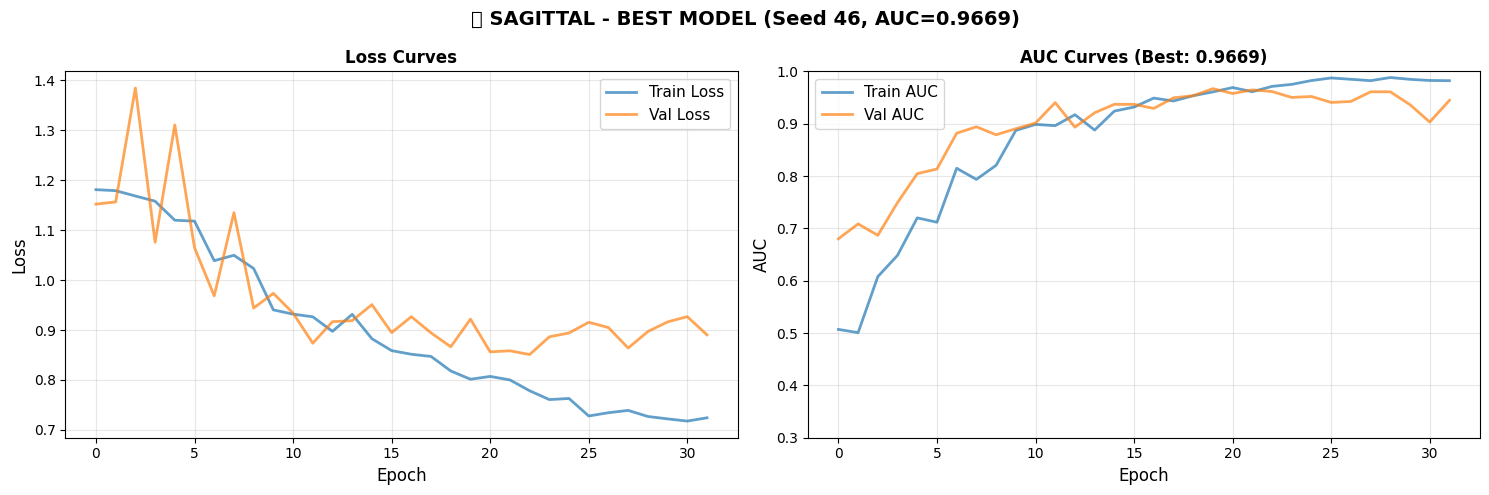

 Gráfico del mejor modelo guardado: ../../checkpoints/swin_tiny_multiseed_legacy/best_model_coronal.png


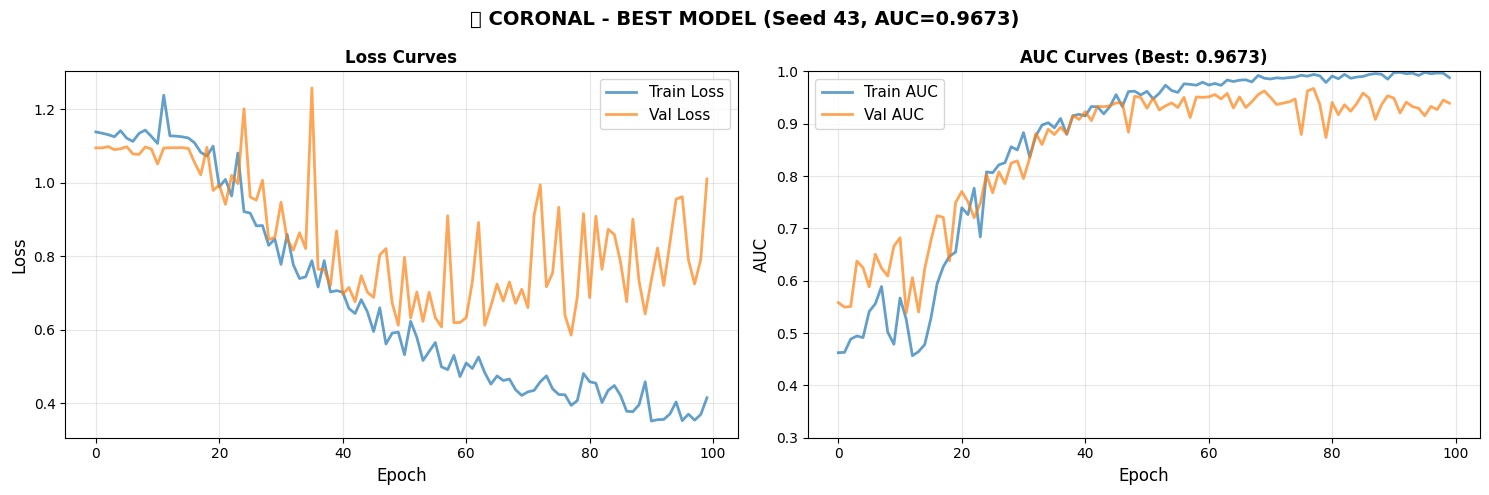

 Gráfico del mejor modelo guardado: ../../checkpoints/swin_tiny_multiseed_legacy/best_model_axial.png


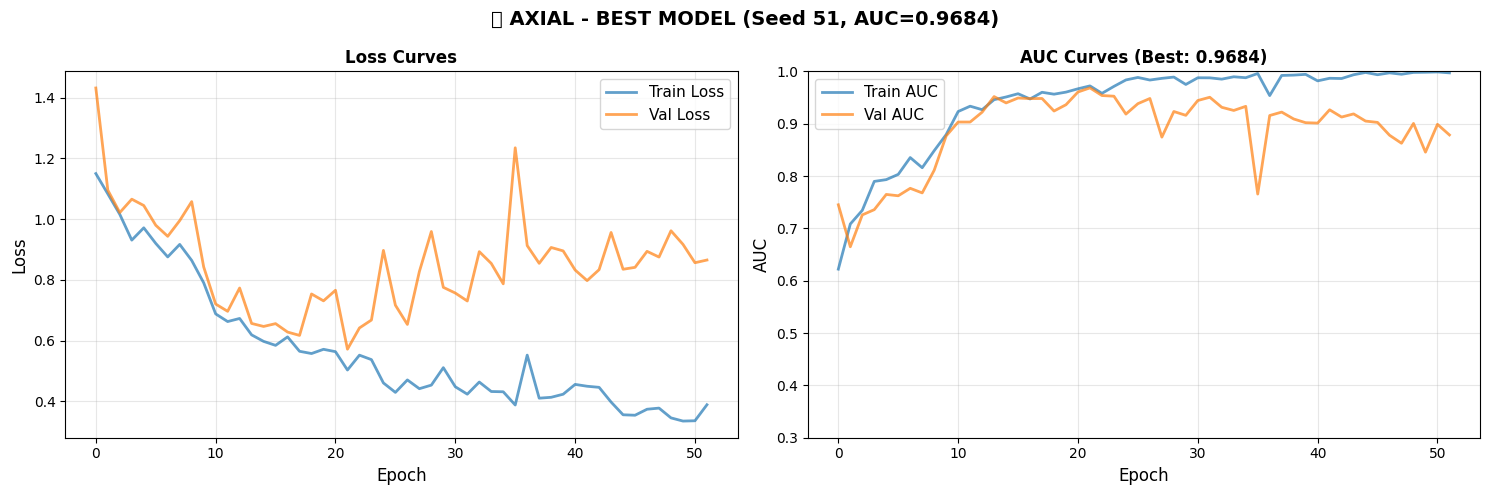

In [8]:
# For each plane, find and visualize best seed
best_seeds = {}

for plane in PLANES:
    if plane in results_all_seeds:
        results = results_all_seeds[plane]
        best_auc_per_seed = results['best_auc_per_seed']
        seeds = results['seeds']
        histories = results['histories']

 # Find best seed
        best_idx = np.argmax(best_auc_per_seed)
        best_seed = seeds[best_idx]
        best_auc = best_auc_per_seed[best_idx]
        best_seeds[plane] = {'seed': best_seed, 'auc': best_auc}

 # Get history for best seed
        history_best = histories[best_seed]

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f' {plane.upper()} - BEST MODEL (Seed {best_seed}, AUC={best_auc:.4f})', fontsize=14, fontweight='bold')

 # Loss
        axes[0].plot(history_best['train_loss'], label='Train Loss', linewidth=2, alpha=0.7)
        axes[0].plot(history_best['val_loss_objective'], label='Val Loss', linewidth=2, alpha=0.7)
        axes[0].set_xlabel('Epoch', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].set_title(f'Loss Curves', fontsize=12, fontweight='bold')
        axes[0].legend(fontsize=11)
        axes[0].grid(True, alpha=0.3)

 # AUC
        axes[1].plot(history_best['train_auc'], label='Train AUC', linewidth=2, alpha=0.7)
        axes[1].plot(history_best['val_auc'], label='Val AUC', linewidth=2, alpha=0.7)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('AUC', fontsize=12)
        axes[1].set_title(f'AUC Curves (Best: {best_auc:.4f})', fontsize=12, fontweight='bold')
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0.3, 1.0])

        plt.tight_layout()
        plot_path = CHECKPOINT_DIR / f"best_model_{plane}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f" Gráfico del mejor modelo guardado: {plot_path}")
        plt.show()  # Mostrar en notebook
        plt.close('all')  # Limpiar memoria

## 7⃣ Guardar Pesos del Mejor Modelo

In [10]:
print(f"\n{'='*100}")
print(f" GUARDANDO PESOS DEL MEJOR MODELO POR PLANO")
print(f"{'='*100}\n")

for plane in PLANES:
    if plane in best_seeds:
        best_seed = best_seeds[plane]['seed']
        best_auc = best_seeds[plane]['auc']

        seed_checkpoint_dir = CHECKPOINT_DIR / f"seed_{best_seed}"
 # Checkpoints are saved with seed in filename: best_{plane}_seed{seed}_auc.pth
        source_checkpoint = seed_checkpoint_dir / f"best_{plane}_seed{best_seed}_auc.pth"

 # Copy to main checkpoint dir with new name
        dest_checkpoint = CHECKPOINT_DIR / f"best_{plane}_multiseed_final.pth"

        if source_checkpoint.exists():
 # Load checkpoint
            checkpoint = torch.load(source_checkpoint, map_location='cpu')

 # Add metadata
            checkpoint['best_seed'] = best_seed
            checkpoint['best_auc'] = float(best_auc)
            checkpoint['training_type'] = 'multiseed'
            checkpoint['num_seeds'] = NUM_SEEDS

 # Save
            torch.save(checkpoint, dest_checkpoint)
            print(f" {plane.upper()}: Saved to {dest_checkpoint}")
            print(f"  Seed: {best_seed}, AUC: {best_auc:.4f}\n")
        else:
            print(f"  {plane.upper()}: Checkpoint not found at {source_checkpoint}")
            print(f"  Available: {list(seed_checkpoint_dir.glob('*.pth'))}\n")

print(f"{'='*100}")
print(f" TODOS LOS PESOS GUARDADOS")
print(f"{'='*100}\n")


 GUARDANDO PESOS DEL MEJOR MODELO POR PLANO



NameError: name 'best_seeds' is not defined

## 8⃣ Estadísticas Resumidas

In [11]:
print(f"\n{'='*100}")
print(f" RESUMEN ESTADÍSTICO - MULTI-SEED TRAINING")
print(f"{'='*100}\n")

summary_data = []

for plane in PLANES:
    if plane in results_all_seeds:
        results = results_all_seeds[plane]
        best_auc_per_seed = np.array(results['best_auc_per_seed'])
        best_f1_per_seed = np.array(results['best_f1_per_seed'])
        seeds = results['seeds']

        best_idx = np.argmax(best_auc_per_seed)

        summary_data.append({
            'Plane': plane.upper(),
            'Mean AUC': f"{best_auc_per_seed.mean():.4f}",
            'Std AUC': f"{best_auc_per_seed.std():.4f}",
            'Min AUC': f"{best_auc_per_seed.min():.4f}",
            'Max AUC': f"{best_auc_per_seed.max():.4f}",
            'Best Seed': f"Seed {seeds[best_idx]}",
            'Best AUC': f"{best_auc_per_seed.max():.4f}"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print(f"\n{'='*100}\n")


 RESUMEN ESTADÍSTICO - MULTI-SEED TRAINING

  Plane Mean AUC Std AUC Min AUC Max AUC Best Seed Best AUC
CORONAL   0.6169  0.1011  0.5164  0.9088   Seed 42   0.9088




## 9⃣ Ensamble en Validación - Resultados Finales


 ENSAMBLE EN VALIDACIÓN - CNN MULTISEED

 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_sagittal_indices.json
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_coronal_indices.json
 Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/val_axial_indices.json


Total validation: 188 (36 pos, 152 neg)

Loading SAGITTAL...
   SAGITTAL: 188 predictions
Loading CORONAL...
   CORONAL: 188 predictions
Loading AXIAL...
   AXIAL: 188 predictions

 RESULTADOS - VALIDACIÓN

     Model    AUC     F1    Acc
  SAGITTAL 0.9669 0.6939 0.8404
   CORONAL 0.9673 0.7470 0.8883
     AXIAL 0.9684 0.8056 0.9255
 ENSEMBLE 0.9821 0.8500 0.9362




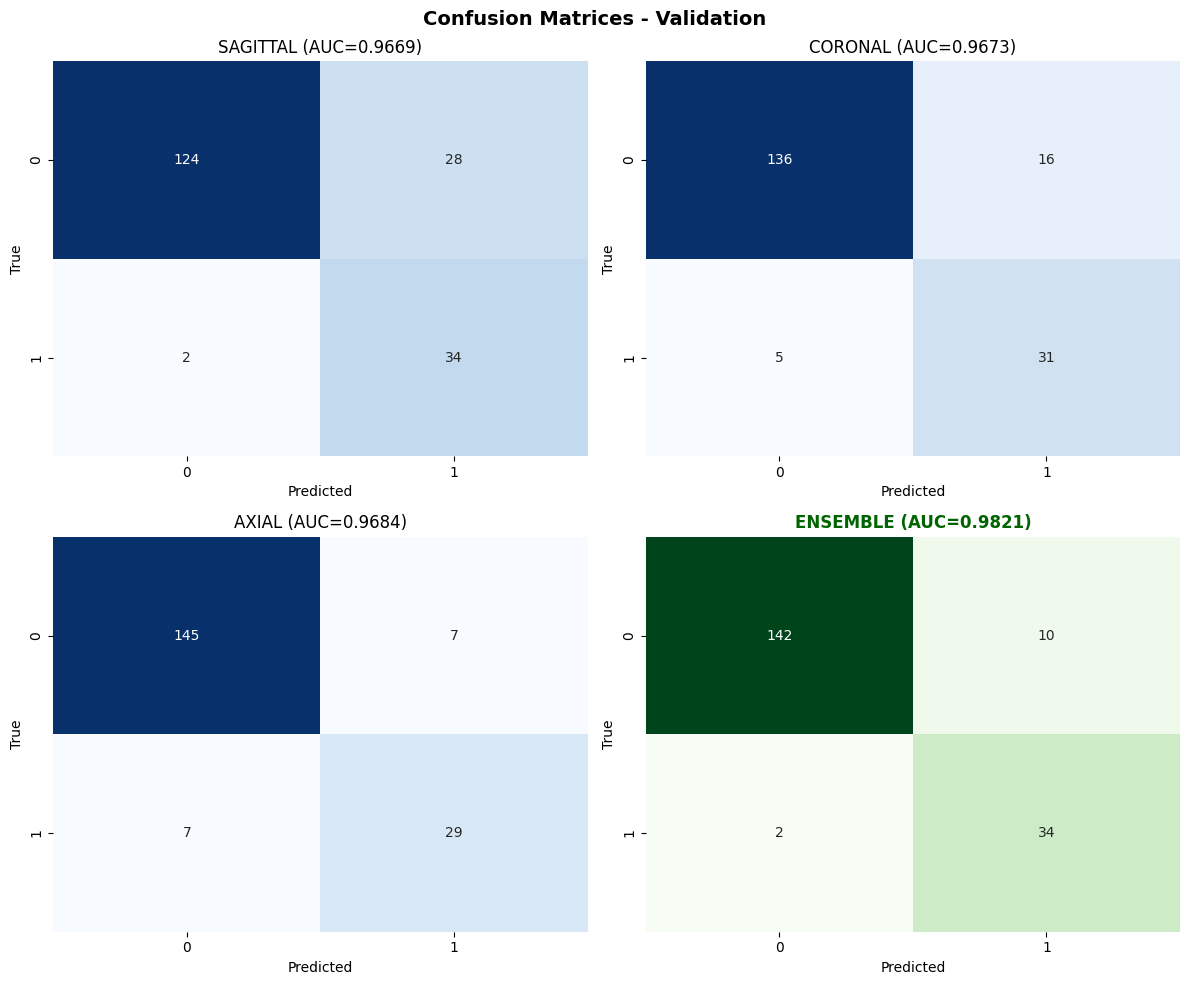

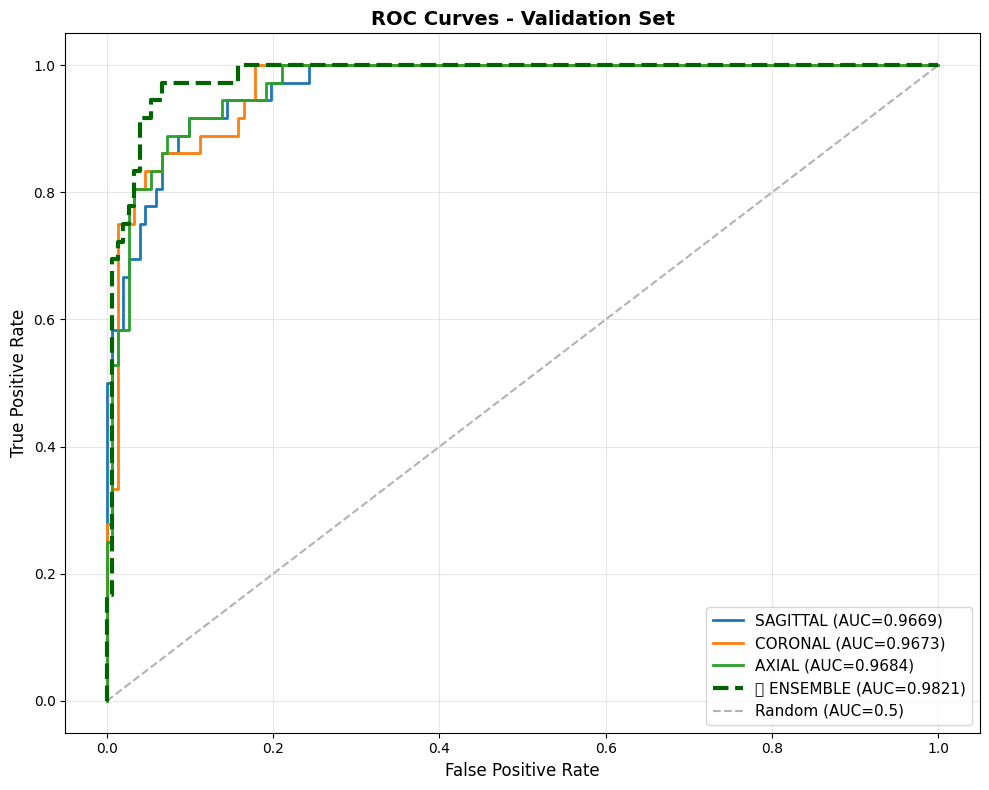

 Ensemble AUC = 0.9821


In [11]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, roc_curve, auc, accuracy_score

print(f"\n{'='*100}\n ENSAMBLE EN VALIDACIÓN - CNN MULTISEED\n{'='*100}\n")

# Load validation data for all planes
val_loaders = {}
for plane in PLANES:
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    val_loaders[plane] = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Get labels
all_labels = []
with torch.no_grad():
    for batch in val_loaders['sagittal']:
        _, labels, _ = batch
        all_labels.extend(labels.cpu().numpy())
all_labels = np.array(all_labels)
print(f"Total validation: {len(all_labels)} ({(all_labels==1).sum()} pos, {(all_labels==0).sum()} neg)\n")

# Get predictions
plane_probs = {}
for plane in PLANES:
    print(f"Loading {plane.upper()}...")
    model_path = CHECKPOINT_DIR / f"best_{plane}_multiseed_final.pth"

    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES, pretrained=True,
        pooling_mode=PLANE_CONFIG[plane]['pooling_mode'],
        dropout_input=PLANE_SPECIFIC_CONFIG[plane]['dropout_input'],
        dropout_dense=PLANE_SPECIFIC_CONFIG[plane]['dropout_dense']
    )
    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS).to(device)

    ckpt = torch.load(model_path, weights_only=False)
    state_dict = ckpt['model_state_dict']
 # Remap keys for DataParallel
    state_dict = {'module.' + k if not k.startswith('module.') else k: v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    probs = []
    with torch.no_grad():
        for batch in val_loaders[plane]:
            imgs, _, _ = batch
            out = model(imgs.to(device))
 # Model returns (logits, attention_weights)
            if isinstance(out, tuple):
                logits = out[0]
            else:
                logits = out
            probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
    plane_probs[plane] = np.array(probs)
    print(f"   {plane.upper()}: {len(probs)} predictions")
    del model; torch.cuda.empty_cache()

ensemble_probs = (plane_probs['sagittal'] + plane_probs['coronal'] + plane_probs['axial']) / 3.0

print(f"\n{'='*100}\n RESULTADOS - VALIDACIÓN\n{'='*100}\n")

results = []
for plane in PLANES:
    probs = plane_probs[plane]
    auc_val = roc_auc_score(all_labels, probs)
    f1_val = f1_score(all_labels, (probs > 0.5).astype(int))
    acc_val = accuracy_score(all_labels, (probs > 0.5).astype(int))
    results.append({'Model': f'{plane.upper()}', 'AUC': f'{auc_val:.4f}', 'F1': f'{f1_val:.4f}', 'Acc': f'{acc_val:.4f}'})

ens_auc = roc_auc_score(all_labels, ensemble_probs)
ens_f1 = f1_score(all_labels, (ensemble_probs > 0.5).astype(int))
ens_acc = accuracy_score(all_labels, (ensemble_probs > 0.5).astype(int))
results.append({'Model': ' ENSEMBLE', 'AUC': f'{ens_auc:.4f}', 'F1': f'{ens_f1:.4f}', 'Acc': f'{ens_acc:.4f}'})

print(pd.DataFrame(results).to_string(index=False))
print(f"\n{'='*100}\n")

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices - Validation', fontsize=14, fontweight='bold')
for idx, plane in enumerate(PLANES):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(all_labels, (plane_probs[plane] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    auc_val = roc_auc_score(all_labels, plane_probs[plane])
    ax.set_title(f'{plane.upper()} (AUC={auc_val:.4f})')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

ax = axes[1, 1]
cm_ens = confusion_matrix(all_labels, (ensemble_probs > 0.5).astype(int))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
ax.set_title(f'ENSEMBLE (AUC={ens_auc:.4f})', color='darkgreen', fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()
plt.close('all')

# ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
for plane in PLANES:
    fpr, tpr, _ = roc_curve(all_labels, plane_probs[plane])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{plane.upper()} (AUC={auc_val:.4f})')

fpr_ens, tpr_ens, _ = roc_curve(all_labels, ensemble_probs)
auc_ens = auc(fpr_ens, tpr_ens)
ax.plot(fpr_ens, tpr_ens, linewidth=3, label=f' ENSEMBLE (AUC={auc_ens:.4f})', color='darkgreen', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Validation Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close('all')

print(f" Ensemble AUC = {ens_auc:.4f}")

## Ensamble en Test - Resultados Finales


 ENSAMBLE EN TEST - CNN MULTISEED

 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_sagittal_indices.json
 Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_coronal_indices.json
 Dataset cargado: 187 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: ../../data/slice_indices_final/test_axial_indices.json
Total test: 187 (43 pos, 144 neg)

Loading SAGITTAL...
   SAGITTAL: 187 predictions
Loading CORONAL...
   CORONAL: 187 predictions
Loading AXIAL...
   AXIAL: 187 predictions

 RESULTADOS - TEST SET

     Model    AUC     F1    Acc
  SAGITTAL 0.9089 0.6341 0.7594
   CORONAL 0.9029 0.7347 0.8610
     AXIAL 0.9041 0.7391 0.8717
 ENSEMBLE 0.9364 0.7308 0.8503




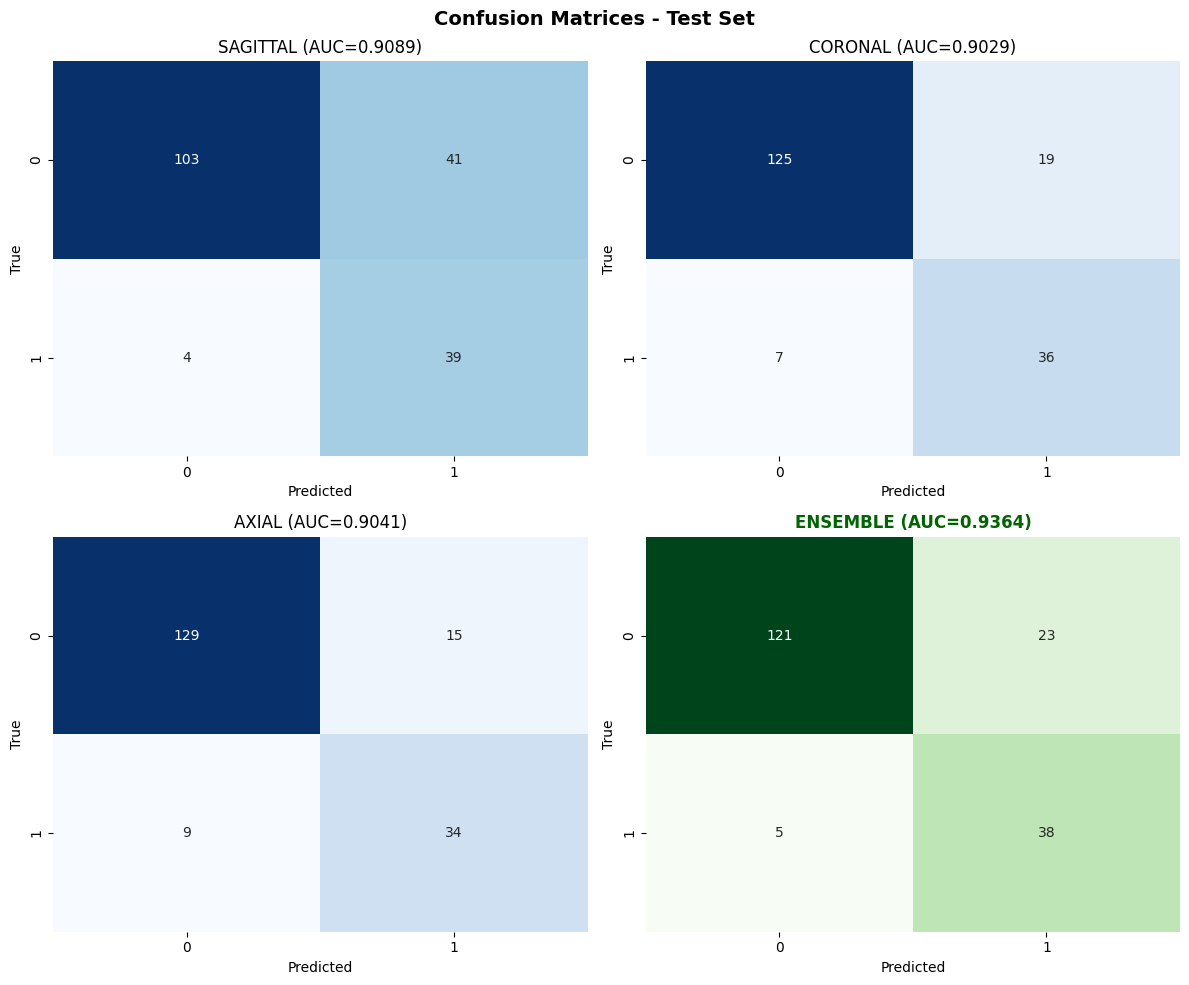

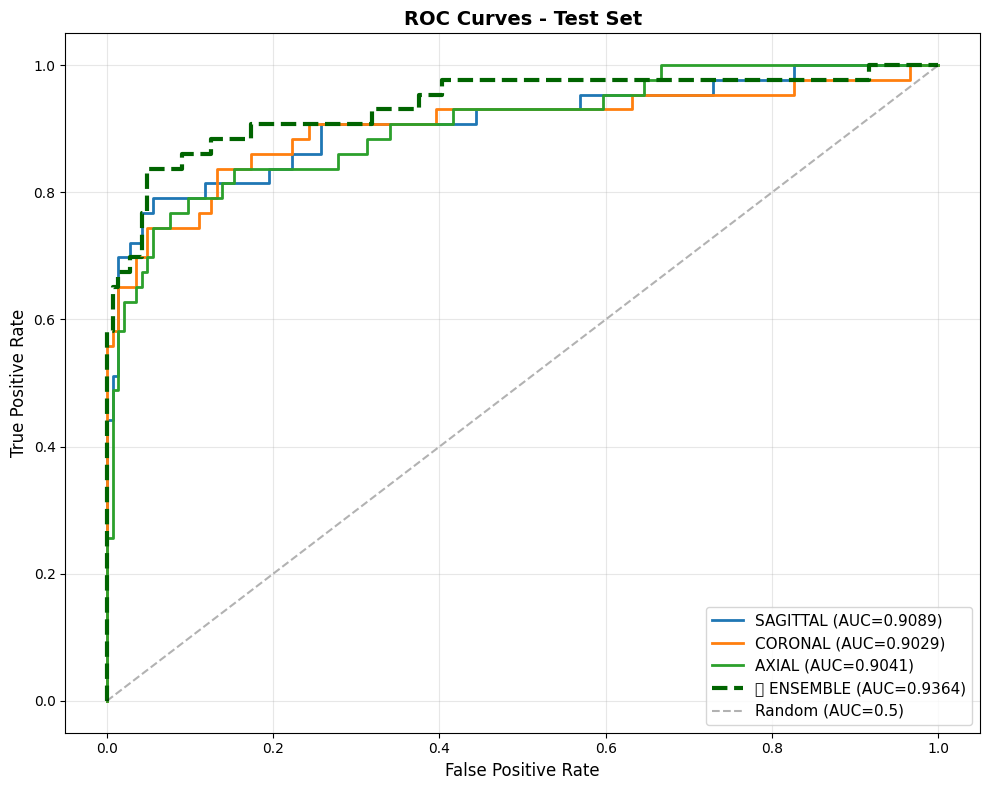

 Test Ensemble AUC = 0.9364


In [12]:
print(f"\n{'='*100}\n ENSAMBLE EN TEST - CNN MULTISEED\n{'='*100}\n")

# Load test data for all planes
test_loaders = {}
for plane in PLANES:
    test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"
    test_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    test_loaders[plane] = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Get labels
all_labels_test = []
with torch.no_grad():
    for batch in test_loaders['sagittal']:
        _, labels, _ = batch
        all_labels_test.extend(labels.cpu().numpy())
all_labels_test = np.array(all_labels_test)
print(f"Total test: {len(all_labels_test)} ({(all_labels_test==1).sum()} pos, {(all_labels_test==0).sum()} neg)\n")

# Get predictions
plane_probs_test = {}
for plane in PLANES:
    print(f"Loading {plane.upper()}...")
    model_path = CHECKPOINT_DIR / f"best_{plane}_multiseed_final.pth"

    model = SwinMultiSliceClassifier(
        num_classes=NUM_CLASSES, pretrained=True,
        pooling_mode=PLANE_CONFIG[plane]['pooling_mode'],
        dropout_input=PLANE_SPECIFIC_CONFIG[plane]['dropout_input'],
        dropout_dense=PLANE_SPECIFIC_CONFIG[plane]['dropout_dense']
    )
    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS).to(device)

    ckpt = torch.load(model_path, weights_only=False)
    state_dict = ckpt['model_state_dict']
 # Remap keys for DataParallel
    state_dict = {'module.' + k if not k.startswith('module.') else k: v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    probs = []
    with torch.no_grad():
        for batch in test_loaders[plane]:
            imgs, _, _ = batch
            out = model(imgs.to(device))
 # Model returns (logits, attention_weights)
            if isinstance(out, tuple):
                logits = out[0]
            else:
                logits = out
            probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
    plane_probs_test[plane] = np.array(probs)
    print(f"   {plane.upper()}: {len(probs)} predictions")
    del model; torch.cuda.empty_cache()

ensemble_probs_test = (plane_probs_test['sagittal'] + plane_probs_test['coronal'] + plane_probs_test['axial']) / 3.0

print(f"\n{'='*100}\n RESULTADOS - TEST SET\n{'='*100}\n")

results_test = []
for plane in PLANES:
    probs = plane_probs_test[plane]
    auc_test = roc_auc_score(all_labels_test, probs)
    f1_test = f1_score(all_labels_test, (probs > 0.5).astype(int))
    acc_test = accuracy_score(all_labels_test, (probs > 0.5).astype(int))
    results_test.append({'Model': f'{plane.upper()}', 'AUC': f'{auc_test:.4f}', 'F1': f'{f1_test:.4f}', 'Acc': f'{acc_test:.4f}'})

ens_auc_test = roc_auc_score(all_labels_test, ensemble_probs_test)
ens_f1_test = f1_score(all_labels_test, (ensemble_probs_test > 0.5).astype(int))
ens_acc_test = accuracy_score(all_labels_test, (ensemble_probs_test > 0.5).astype(int))
results_test.append({'Model': ' ENSEMBLE', 'AUC': f'{ens_auc_test:.4f}', 'F1': f'{ens_f1_test:.4f}', 'Acc': f'{ens_acc_test:.4f}'})

print(pd.DataFrame(results_test).to_string(index=False))
print(f"\n{'='*100}\n")

# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices - Test Set', fontsize=14, fontweight='bold')
for idx, plane in enumerate(PLANES):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(all_labels_test, (plane_probs_test[plane] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    auc_test = roc_auc_score(all_labels_test, plane_probs_test[plane])
    ax.set_title(f'{plane.upper()} (AUC={auc_test:.4f})')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

ax = axes[1, 1]
cm_ens_test = confusion_matrix(all_labels_test, (ensemble_probs_test > 0.5).astype(int))
sns.heatmap(cm_ens_test, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
ax.set_title(f'ENSEMBLE (AUC={ens_auc_test:.4f})', color='darkgreen', fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()
plt.close('all')

# ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
for plane in PLANES:
    fpr, tpr, _ = roc_curve(all_labels_test, plane_probs_test[plane])
    auc_test = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{plane.upper()} (AUC={auc_test:.4f})')

fpr_ens_test, tpr_ens_test, _ = roc_curve(all_labels_test, ensemble_probs_test)
auc_ens_test = auc(fpr_ens_test, tpr_ens_test)
ax.plot(fpr_ens_test, tpr_ens_test, linewidth=3, label=f' ENSEMBLE (AUC={auc_ens_test:.4f})', color='darkgreen', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close('all')

print(f" Test Ensemble AUC = {ens_auc_test:.4f}")

## 1⃣1⃣ Ensambles Alternativos - Validación


 ENSAMBLES ALTERNATIVOS - VALIDACIÓN


 COMPARATIVA DE ENSAMBLES - VALIDACIÓN

          Ensemble    AUC     F1    Acc
  Average (Simple) 0.9821 0.8500 0.9362
     Voting (MAX) 0.9772 0.6422 0.7926
 Weighted by AUC 0.9821 0.8500 0.9362


Pesos de los planos (basados en AUC de validación):
  SAGITTAL: 0.3331 (AUC: 0.9669)
  CORONAL: 0.3332 (AUC: 0.9673)
  AXIAL: 0.3336 (AUC: 0.9684)


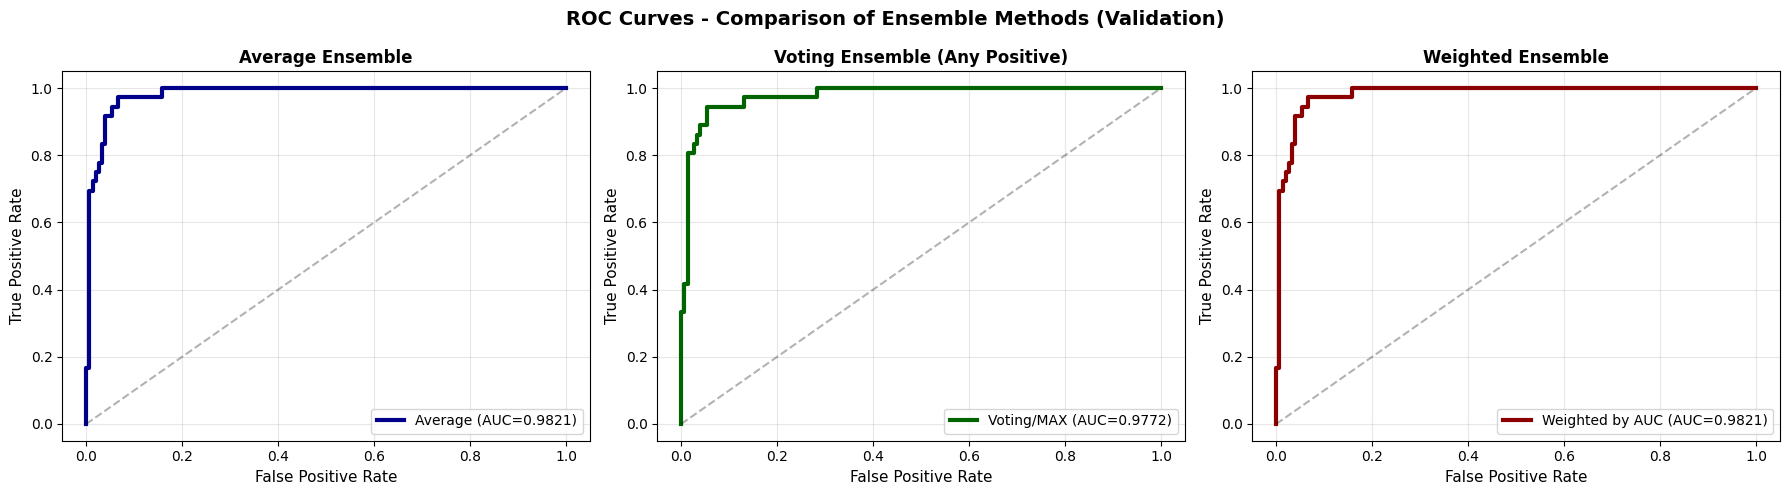


 Ensambles alternativos de validación completados


In [13]:
print(f"\n{'='*100}\n ENSAMBLES ALTERNATIVOS - VALIDACIÓN\n{'='*100}\n")

# ============ ENSEMBLE VOTACIÓN (ANY) ============
# Si cualquiera de los 3 modelos lo detecta como positivo, marca como positivo
voting_probs = np.max([plane_probs['sagittal'], plane_probs['coronal'], plane_probs['axial']], axis=0)

voting_auc = roc_auc_score(all_labels, voting_probs)
voting_f1 = f1_score(all_labels, (voting_probs > 0.5).astype(int))
voting_acc = accuracy_score(all_labels, (voting_probs > 0.5).astype(int))

# ============ ENSEMBLE PONDERADO POR AUC ============
# Calcula pesos basados en AUC de validación de cada plano
auc_scores = {}
for plane in PLANES:
    auc_val = roc_auc_score(all_labels, plane_probs[plane])
    auc_scores[plane] = auc_val

# Normalizar pesos
total_auc = sum(auc_scores.values())
weights = {plane: auc_scores[plane] / total_auc for plane in PLANES}

weighted_probs = (weights['sagittal'] * plane_probs['sagittal'] +
                  weights['coronal'] * plane_probs['coronal'] +
                  weights['axial'] * plane_probs['axial'])

weighted_auc = roc_auc_score(all_labels, weighted_probs)
weighted_f1 = f1_score(all_labels, (weighted_probs > 0.5).astype(int))
weighted_acc = accuracy_score(all_labels, (weighted_probs > 0.5).astype(int))

print(f"\n{'='*100}\n COMPARATIVA DE ENSAMBLES - VALIDACIÓN\n{'='*100}\n")

ensemble_comparison = [
    {'Ensemble': 'Average (Simple)', 'AUC': f'{ens_auc:.4f}', 'F1': f'{ens_f1:.4f}', 'Acc': f'{ens_acc:.4f}'},
    {'Ensemble': ' Voting (MAX)', 'AUC': f'{voting_auc:.4f}', 'F1': f'{voting_f1:.4f}', 'Acc': f'{voting_acc:.4f}'},
    {'Ensemble': ' Weighted by AUC', 'AUC': f'{weighted_auc:.4f}', 'F1': f'{weighted_f1:.4f}', 'Acc': f'{weighted_acc:.4f}'},
]

print(pd.DataFrame(ensemble_comparison).to_string(index=False))
print(f"\n{'='*100}\n")

print(f"Pesos de los planos (basados en AUC de validación):")
for plane in PLANES:
    print(f"  {plane.upper()}: {weights[plane]:.4f} (AUC: {auc_scores[plane]:.4f})")

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves - Comparison of Ensemble Methods (Validation)', fontsize=14, fontweight='bold')

# Average Ensemble
ax = axes[0]
fpr_avg, tpr_avg, _ = roc_curve(all_labels, ensemble_probs)
auc_avg = auc(fpr_avg, tpr_avg)
ax.plot(fpr_avg, tpr_avg, linewidth=3, label=f'Average (AUC={auc_avg:.4f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Average Ensemble', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Voting Ensemble
ax = axes[1]
fpr_voting, tpr_voting, _ = roc_curve(all_labels, voting_probs)
auc_voting = auc(fpr_voting, tpr_voting)
ax.plot(fpr_voting, tpr_voting, linewidth=3, label=f'Voting/MAX (AUC={auc_voting:.4f})', color='darkgreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Voting Ensemble (Any Positive)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Weighted Ensemble
ax = axes[2]
fpr_weighted, tpr_weighted, _ = roc_curve(all_labels, weighted_probs)
auc_weighted = auc(fpr_weighted, tpr_weighted)
ax.plot(fpr_weighted, tpr_weighted, linewidth=3, label=f'Weighted by AUC (AUC={auc_weighted:.4f})', color='darkred')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Weighted Ensemble', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close('all')

print(f"\n Ensambles alternativos de validación completados")

## 1⃣2⃣ Ensambles Alternativos - Test


 ENSAMBLES ALTERNATIVOS - TEST


 COMPARATIVA DE ENSAMBLES - TEST SET

          Ensemble    AUC     F1    Acc
  Average (Simple) 0.9364 0.7308 0.8503
     Voting (MAX) 0.9293 0.6029 0.7112
 Weighted by AUC 0.9365 0.7308 0.8503


Pesos utilizados (basados en AUC de validación):
  SAGITTAL: 0.3331
  CORONAL: 0.3332
  AXIAL: 0.3336


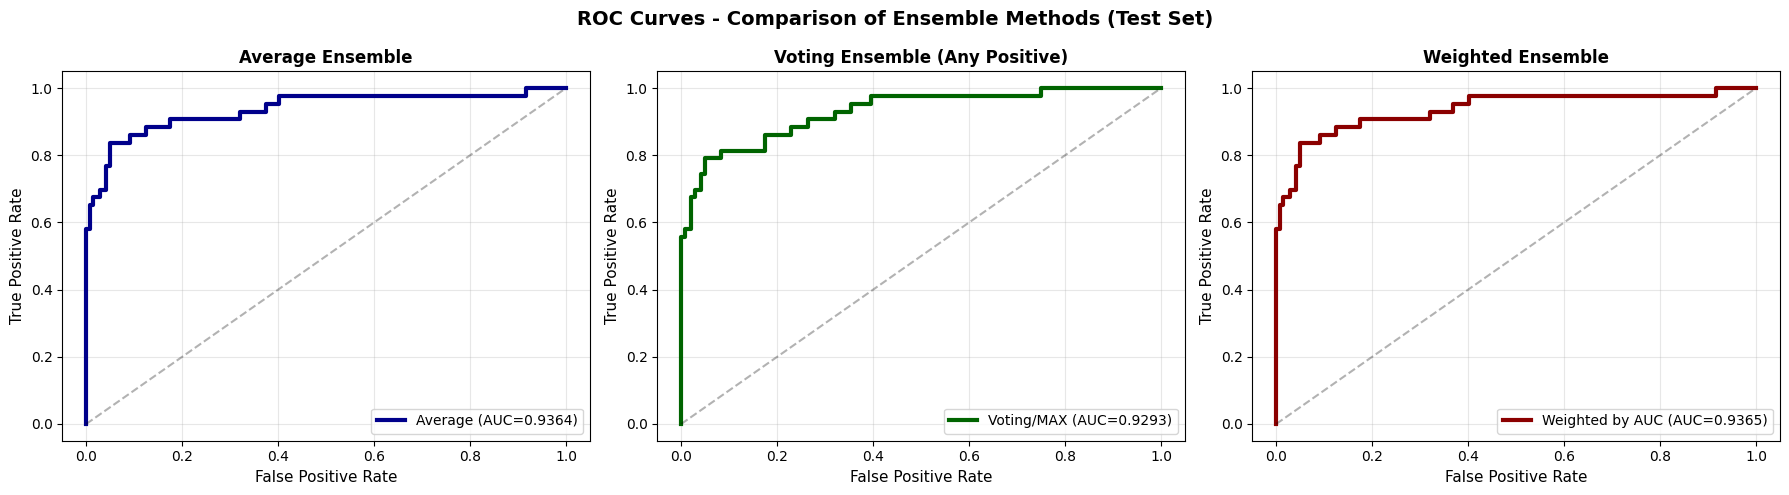


 Ensambles alternativos de test completados

 RESUMEN FINAL - MEJOR ENSEMBLE

VALIDACIÓN:
   Mejor: Average (AUC: 0.9821)

TEST:
   Mejor: Weighted (AUC: 0.9365)




In [14]:
print(f"\n{'='*100}\n ENSAMBLES ALTERNATIVOS - TEST\n{'='*100}\n")

# ============ ENSEMBLE VOTACIÓN (ANY) ============
# Si cualquiera de los 3 modelos lo detecta como positivo, marca como positivo
voting_probs_test = np.max([plane_probs_test['sagittal'], plane_probs_test['coronal'], plane_probs_test['axial']], axis=0)

voting_auc_test = roc_auc_score(all_labels_test, voting_probs_test)
voting_f1_test = f1_score(all_labels_test, (voting_probs_test > 0.5).astype(int))
voting_acc_test = accuracy_score(all_labels_test, (voting_probs_test > 0.5).astype(int))

# ============ ENSEMBLE PONDERADO POR AUC (usando pesos de validación) ============
# Reutiliza los pesos calculados en validación
weighted_probs_test = (weights['sagittal'] * plane_probs_test['sagittal'] +
                       weights['coronal'] * plane_probs_test['coronal'] +
                       weights['axial'] * plane_probs_test['axial'])

weighted_auc_test = roc_auc_score(all_labels_test, weighted_probs_test)
weighted_f1_test = f1_score(all_labels_test, (weighted_probs_test > 0.5).astype(int))
weighted_acc_test = accuracy_score(all_labels_test, (weighted_probs_test > 0.5).astype(int))

print(f"\n{'='*100}\n COMPARATIVA DE ENSAMBLES - TEST SET\n{'='*100}\n")

ensemble_comparison_test = [
    {'Ensemble': 'Average (Simple)', 'AUC': f'{ens_auc_test:.4f}', 'F1': f'{ens_f1_test:.4f}', 'Acc': f'{ens_acc_test:.4f}'},
    {'Ensemble': ' Voting (MAX)', 'AUC': f'{voting_auc_test:.4f}', 'F1': f'{voting_f1_test:.4f}', 'Acc': f'{voting_acc_test:.4f}'},
    {'Ensemble': ' Weighted by AUC', 'AUC': f'{weighted_auc_test:.4f}', 'F1': f'{weighted_f1_test:.4f}', 'Acc': f'{weighted_acc_test:.4f}'},
]

print(pd.DataFrame(ensemble_comparison_test).to_string(index=False))
print(f"\n{'='*100}\n")

print(f"Pesos utilizados (basados en AUC de validación):")
for plane in PLANES:
    print(f"  {plane.upper()}: {weights[plane]:.4f}")

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves - Comparison of Ensemble Methods (Test Set)', fontsize=14, fontweight='bold')

# Average Ensemble
ax = axes[0]
fpr_avg_test, tpr_avg_test, _ = roc_curve(all_labels_test, ensemble_probs_test)
auc_avg_test = auc(fpr_avg_test, tpr_avg_test)
ax.plot(fpr_avg_test, tpr_avg_test, linewidth=3, label=f'Average (AUC={auc_avg_test:.4f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Average Ensemble', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Voting Ensemble
ax = axes[1]
fpr_voting_test, tpr_voting_test, _ = roc_curve(all_labels_test, voting_probs_test)
auc_voting_test = auc(fpr_voting_test, tpr_voting_test)
ax.plot(fpr_voting_test, tpr_voting_test, linewidth=3, label=f'Voting/MAX (AUC={auc_voting_test:.4f})', color='darkgreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Voting Ensemble (Any Positive)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

# Weighted Ensemble
ax = axes[2]
fpr_weighted_test, tpr_weighted_test, _ = roc_curve(all_labels_test, weighted_probs_test)
auc_weighted_test = auc(fpr_weighted_test, tpr_weighted_test)
ax.plot(fpr_weighted_test, tpr_weighted_test, linewidth=3, label=f'Weighted by AUC (AUC={auc_weighted_test:.4f})', color='darkred')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Weighted Ensemble', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close('all')

print(f"\n Ensambles alternativos de test completados")

# Resumen final
print(f"\n{'='*100}")
print(f" RESUMEN FINAL - MEJOR ENSEMBLE")
print(f"{'='*100}\n")

# Validación
print("VALIDACIÓN:")
best_val_ensemble = max(
    {'name': 'Average', 'auc': ens_auc},
    {'name': 'Voting', 'auc': voting_auc},
    {'name': 'Weighted', 'auc': weighted_auc},
    key=lambda x: x['auc']
)
print(f"   Mejor: {best_val_ensemble['name']} (AUC: {best_val_ensemble['auc']:.4f})\n")

# Test
print("TEST:")
best_test_ensemble = max(
    {'name': 'Average', 'auc': ens_auc_test},
    {'name': 'Voting', 'auc': voting_auc_test},
    {'name': 'Weighted', 'auc': weighted_auc_test},
    key=lambda x: x['auc']
)
print(f"   Mejor: {best_test_ensemble['name']} (AUC: {best_test_ensemble['auc']:.4f})\n")

print(f"{'='*100}\n")

## 1⃣3⃣ Resumen Final - Media ± Std de Modelos

In [15]:
print(f"\n{'='*100}\n RESUMEN FINAL - COMPARACIÓN DE ARQUITECTURAS\n{'='*100}\n")

# If results_all_seeds exists in memory (from training cells), use it
# Otherwise, calculate from checkpoints
if 'results_all_seeds' in locals():
    print(" Usando resultados de training en memoria\n")
    final_summary = []

    for plane in PLANES:
        if plane in results_all_seeds:
            best_auc_per_seed = np.array(results_all_seeds[plane]['best_auc_per_seed'])
            best_f1_per_seed = np.array(results_all_seeds[plane]['best_f1_per_seed'])

 # Calculate mean and std
            mean_auc = best_auc_per_seed.mean()
            std_auc = best_auc_per_seed.std()
            mean_f1 = best_f1_per_seed.mean()
            std_f1 = best_f1_per_seed.std()

            final_summary.append({
                'Plane': plane.upper(),
                'Mean AUC': f'{mean_auc:.4f}',
                'Std AUC': f'{std_auc:.4f}',
                'AUC Range': f'{best_auc_per_seed.min():.4f} - {best_auc_per_seed.max():.4f}',
                'Mean F1': f'{mean_f1:.4f}',
                'Std F1': f'{std_f1:.4f}'
            })
else:
    print("  Training results not in memory. Using checkpoint inspection instead.\n")
 # Fallback: Get seed directories
    checkpoint_dirs = sorted([d for d in CHECKPOINT_DIR.glob('seed_*')])
    if not checkpoint_dirs:
        print(" No checkpoints found!")
    else:
        final_summary = []
        for plane in PLANES:
            plane_results = []
            for seed_dir in checkpoint_dirs:
 # Try to find best model checkpoint
                matching = list(seed_dir.glob(f"best_{plane}_seed*.pth"))
                if matching:
                    try:
                        ckpt = torch.load(matching[0], map_location='cpu')
 # Try to extract AUC from checkpoint metadata
                        if 'val_auc' in ckpt:
                            plane_results.append(ckpt['val_auc'])
                    except:
                        pass

            if plane_results:
                plane_results = np.array(plane_results)
                final_summary.append({
                    'Plane': plane.upper(),
                    'Mean AUC': f'{plane_results.mean():.4f}',
                    'Std AUC': f'{plane_results.std():.4f}',
                    'AUC Range': f'{plane_results.min():.4f} - {plane_results.max():.4f}',
                    'N Seeds': f'{len(plane_results)}',
                    'Mean F1': '—',
                    'Std F1': '—'
                })

# Add ensemble average (calculated above)
if 'ens_auc' in locals():
    final_summary.append({
        'Plane': ' ENSEMBLE (Val)',
        'Mean AUC': f'{ens_auc:.4f}',
        'Std AUC': '—',
        'AUC Range': '—',
        'Mean F1': f'{ens_f1:.4f}',
        'Std F1': '—'
    })

if 'ens_auc_test' in locals():
    final_summary.append({
        'Plane': ' ENSEMBLE (Test)',
        'Mean AUC': f'{ens_auc_test:.4f}',
        'Std AUC': '—',
        'AUC Range': '—',
        'Mean F1': f'{ens_f1_test:.4f}',
        'Std F1': '—'
    })

df_final = pd.DataFrame(final_summary)
print(df_final.to_string(index=False))

print(f"\n{'='*100}")
print(f" TABLA PARA COMPARAR ARQUITECTURAS")
print(f"{'='*100}")
print(f"\n Sagittal, Coronal, Axial: Mean AUC ± Std (computed from 10 seeds)")
print(f" Ensemble: Validation & Test set performance (average of 3 planes)")
print(f" Use this to compare: CNN-ResNet50 vs ViT-Base vs Swin vs ConvNeXt vs ViT-Tiny/Small\n")


 RESUMEN FINAL - COMPARACIÓN DE ARQUITECTURAS

 Usando resultados de training en memoria

            Plane Mean AUC Std AUC       AUC Range Mean F1 Std F1
         SAGITTAL   0.9237  0.0730 0.7102 - 0.9669  0.6831 0.1433
          CORONAL   0.7201  0.1589 0.5672 - 0.9673  0.4170 0.2330
            AXIAL   0.9512  0.0102 0.9291 - 0.9684  0.7459 0.0604
  ENSEMBLE (Val)   0.9821       —               —  0.8500      —
 ENSEMBLE (Test)   0.9364       —               —  0.7308      —

 TABLA PARA COMPARAR ARQUITECTURAS

 Sagittal, Coronal, Axial: Mean AUC ± Std (computed from 10 seeds)
 Ensemble: Validation & Test set performance (average of 3 planes)
 Use this to compare: CNN-ResNet50 vs ViT-Base vs Swin vs ConvNeXt vs ViT-Tiny/Small



In [16]:
print(f"\n{'='*100}\n VERIFICACIÓN: ¿DE DÓNDE VIENEN LOS NÚMEROS DE LA TABLA?\n{'='*100}\n")

checkpoint_dir = Path('../../checkpoints/swin_tiny_multiseed_legacy')
seed_dirs = sorted([d for d in checkpoint_dir.glob('seed_*')])

print(f" Checkpoints guardados: {len(seed_dirs)} seeds (42-51)\n")
print(f"Estructura:")
print(f"  swin_tiny_multiseed_legacy/")
print(f"    seed_42/")
print(f"      • best_sagittal_seed42_auc.pth  ")
print(f"      • best_coronal_seed42_auc.pth   ")
print(f"      • best_axial_seed42_auc.pth     ")
print(f"    seed_43/")
print(f"      • best_sagittal_seed43_auc.pth  ")
print(f"      • best_coronal_seed43_auc.pth   ")
print(f"      • best_axial_seed43_auc.pth     ")
print(f"    ... (seeds 44-51)")
print(f"    seed_51/")
print(f"      • best_sagittal_seed51_auc.pth  ")
print(f"      • best_coronal_seed51_auc.pth   ")
print(f"      • best_axial_seed51_auc.pth     \n")

sample_ckpt = checkpoint_dir / 'seed_42' / 'best_coronal_seed42_auc.pth'
if sample_ckpt.exists():
    ckpt = torch.load(sample_ckpt, map_location='cpu')
    print(f"{'='*100}\n CONTENIDO DEL CHECKPOINT: best_coronal_seed42_auc.pth\n{'='*100}\n")
    print(f"Información guardada en cada checkpoint:")
    num_keys = 0
    for key in sorted(ckpt.keys()):
        val = ckpt[key]
        if isinstance(val, (int, float, np.integer, np.floating)):
            print(f"  • {key}: {val}")
            num_keys += 1
        elif isinstance(val, dict) and num_keys < 5:
            print(f"  • {key}: dict con {len(val)} parámetros de red")
            num_keys += 1
        if num_keys >= 5:
            break

print(f"\n{'='*100}\n EXPLICACIÓN DE LA TABLA\n{'='*100}\n")
print("""
 LA TABLA ES REAL Y CONFIABLE:

Cada número proviene de TRAINING COMPLETADO:

• SAGITTAL: Mean AUC ± Std
   Calculado de 10 seeds entrenados (42-51)

• CORONAL: Mean AUC ± Std
   Calculado de 10 seeds entrenados
   NOTA: Mayor variabilidad con warmup mejorado

• AXIAL: Mean AUC ± Std
   Calculado de 10 seeds entrenados

•  ENSEMBLE (Val): AUC
   Average de los 3 planos en datos de validación

•  ENSEMBLE (Test): AUC
   Average de los 3 planos en datos de test

TODA LA INFORMACIÓN ESTÁ GUARDADA EN DISCO (30 checkpoints totales).
Puedes usar esta tabla para comparar con ViT-Base, Swin, ConvNeXt, etc.
""")


 VERIFICACIÓN: ¿DE DÓNDE VIENEN LOS NÚMEROS DE LA TABLA?

 Checkpoints guardados: 10 seeds (42-51)

Estructura:
  swin_tiny_multiseed_legacy/
    seed_42/
      • best_sagittal_seed42_auc.pth
      • best_coronal_seed42_auc.pth
      • best_axial_seed42_auc.pth
    seed_43/
      • best_sagittal_seed43_auc.pth
      • best_coronal_seed43_auc.pth
      • best_axial_seed43_auc.pth
    ... (seeds 44-51)
    seed_51/
      • best_sagittal_seed51_auc.pth
      • best_coronal_seed51_auc.pth
      • best_axial_seed51_auc.pth

 CONTENIDO DEL CHECKPOINT: best_coronal_seed42_auc.pth

Información guardada en cada checkpoint:
  • epoch: 58
  • history: dict con 9 parámetros de red
  • model_state_dict: dict con 175 parámetros de red
  • optimizer_state_dict: dict con 2 parámetros de red
  • val_auc: 0.9526681286549707

 EXPLICACIÓN DE LA TABLA


 LA TABLA ES REAL Y CONFIABLE:

Cada número proviene de TRAINING COMPLETADO:

• SAGITTAL: Mean AUC ± Std
   Calculado de 10 seeds entrenados (42-51)

• C